# Hard & Soft Clustering

**Hard Clustering**: assign each point in a data set to a cluster or to noise, no mixed memberships.

**Soft Clustering**: each point is assigned a i-dimensional vector of probabilities representing how much the point is a member of the i-th cluster. 



https://hdbscan.readthedocs.io/en/latest/soft_clustering.html

## Data preparation

In [70]:
# Import libraries
from sklearn import datasets
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import hdbscan
from hdbscan import all_points_membership_vectors


In [71]:
# Load digits dataset
digits = datasets.load_digits()
data = digits.data
target = digits.target

data, target

(array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ..., 10.,  0.,  0.],
        [ 0.,  0.,  0., ..., 16.,  9.,  0.],
        ...,
        [ 0.,  0.,  1., ...,  6.,  0.,  0.],
        [ 0.,  0.,  2., ..., 12.,  0.,  0.],
        [ 0.,  0., 10., ..., 12.,  1.,  0.]], shape=(1797, 64)),
 array([0, 1, 2, ..., 8, 9, 8], shape=(1797,)))

In [72]:
# Print target distribution
unique, counts = np.unique(target, return_counts=True)

unique, counts

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 array([178, 182, 177, 183, 181, 182, 181, 179, 174, 180]))

In [73]:
# Project data into two dimensions to visualize via t-SNE
projection = TSNE().fit_transform(data)

projection

array([[ -2.973032 , -54.91423  ],
       [ 10.365049 ,  11.784241 ],
       [-13.572787 ,  18.610283 ],
       ...,
       [ -5.9266906,  10.66012  ],
       [-21.0435   , -15.280559 ],
       [-14.019561 ,   6.9801397]], shape=(1797, 2), dtype=float32)

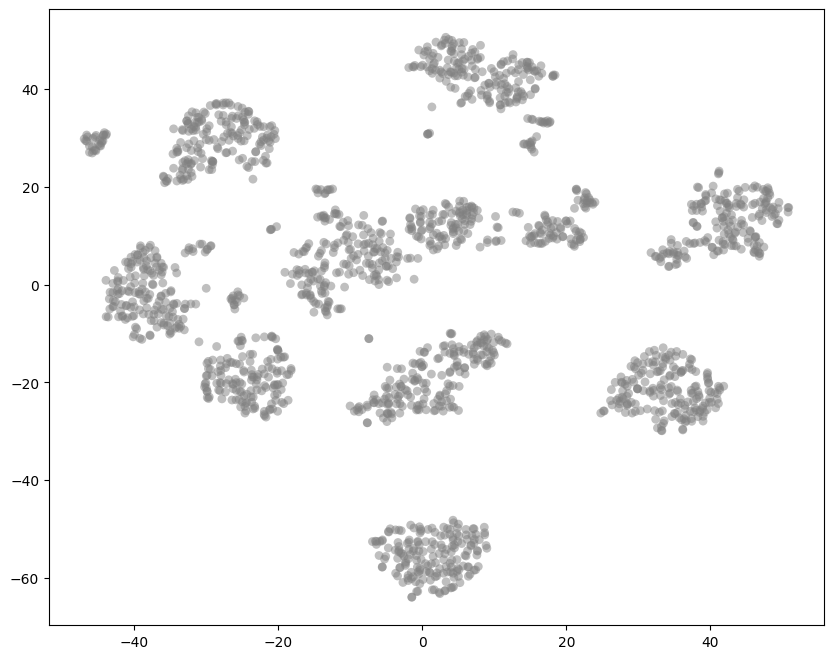

In [74]:
# Plot data in 2-dimensional space
# Plotting arguments: s = marker size, c = color (RGBA array), alpha = transparency
plt.figure(figsize=(10, 8))
plt.scatter(*projection.T, s=40, linewidth=0, color=[0.5, 0.5, 0.5], alpha=0.5, edgecolors='none')
# plt.savefig("images/digits_tSNE")

In [75]:
# Define min-max scaling function
def min_max_scale(array):
    return (array - array.min()) / (array.max() - array.min())

## Hard Clustering

In [76]:
# Hard Clustering
hard_clusterer = hdbscan.HDBSCAN(min_cluster_size=10, prediction_data=False).fit(data)

d:\Projects\Thesis\PoliTopic\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
d:\Projects\Thesis\PoliTopic\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [77]:
# Generated labels: numpy ndarray
hard_clusterer.labels_

array([ 2,  9, -1, ..., -1, -1, -1], shape=(1797,))

In [78]:
# Count number of data points in each cluster
hard_clust_dict = dict()

for i in hard_clusterer.labels_:
    if int(i) in hard_clust_dict:
        hard_clust_dict[int(i)] += 1
    else:
        hard_clust_dict[int(i)] = 1

In [79]:
# Show how many clusters are found: -1 represents noise cluster
len(hard_clust_dict.keys())

13

In [80]:
# Show occurrences in each cluster
hard_clust_dict

{2: 172,
 9: 18,
 -1: 839,
 5: 159,
 11: 70,
 3: 131,
 1: 136,
 4: 102,
 8: 68,
 6: 26,
 7: 19,
 10: 37,
 0: 20}

In [81]:
# Sort dictionary by label
sorted_hard_dict = dict(sorted(hard_clust_dict.items(), key=lambda item: item[0])) 

sorted_hard_dict

{-1: 839,
 0: 20,
 1: 136,
 2: 172,
 3: 131,
 4: 102,
 5: 159,
 6: 26,
 7: 19,
 8: 68,
 9: 18,
 10: 37,
 11: 70}

In [82]:
# Show probabilities computed by hard clustering
hard_clusterer.probabilities_

array([0.95807643, 0.95562709, 0.        , ..., 0.        , 0.        ,
       0.        ], shape=(1797,))

In [83]:
print(hard_clusterer.probabilities_.max())

1.0


In [84]:
# Compute mean of non-zero elements in probabilities
arr = np.array(hard_clusterer.probabilities_)
nonzero = arr[arr != 0]
mean_nonzero = nonzero.mean() if nonzero.size > 0 else np.nan
print(mean_nonzero)

0.8852058268344273


In [85]:
# Set colors for hard clusters
hard_color_palette = sns.color_palette('Paired', len(hard_clust_dict.keys())-1)
hard_cluster_colors = [hard_color_palette[x] if x >= 0
                  else (0.5, 0.5, 0.5)
                  for x in hard_clusterer.labels_]
hard_member_colors = [sns.desaturate(x, p) for x, p in
                         zip(hard_cluster_colors, hard_clusterer.probabilities_)]

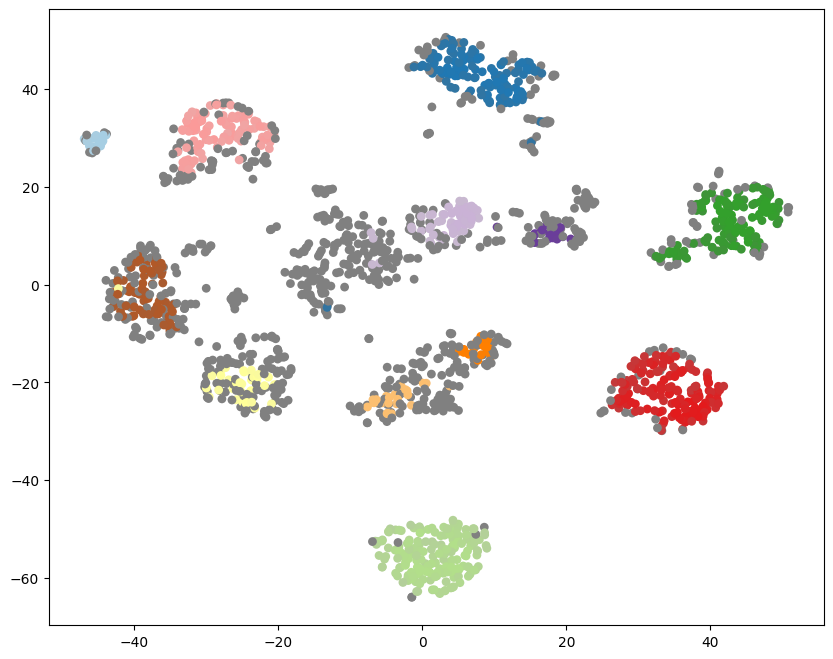

In [86]:
# Plot hard clustering results
plt.figure(figsize=(10, 8))
plt.scatter(*projection.T, s=40, linewidth=0, c=hard_member_colors, edgecolors='none')
# plt.savefig("images/hard_clustering_o")

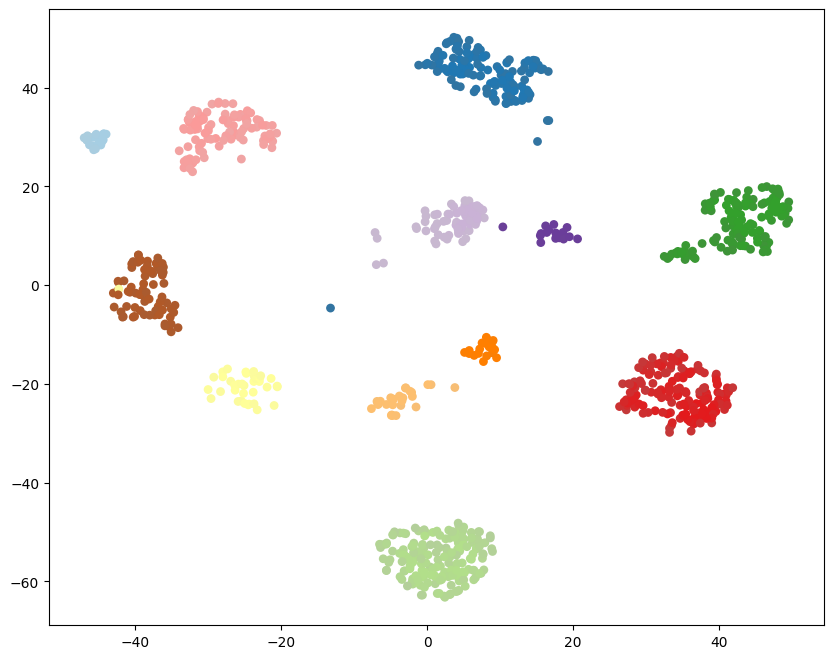

In [87]:
# Exclude noise points for better visualization
mask = np.array(hard_clusterer.labels_) >= 0
proj_masked = projection[mask]
colors_masked = [c for c, m in zip(hard_member_colors, mask) if m]
plt.figure(figsize=(10, 8))
plt.scatter(*proj_masked.T, s=40, linewidth=0, c=colors_masked, edgecolors='none', alpha=1)
# plt.savefig("images/hard_clustering")

## Soft Clustering

In [88]:
# Soft Clustering
soft_clusterer = hdbscan.HDBSCAN(min_cluster_size=10, prediction_data=True).fit(data)

d:\Projects\Thesis\PoliTopic\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
d:\Projects\Thesis\PoliTopic\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [89]:
# Generated labels: numpy ndarray
soft_clusterer.labels_

array([ 2,  9, -1, ..., -1, -1, -1], shape=(1797,))

In [90]:
# Count number of data points in each cluster
soft_clust_dict = dict()

for i in soft_clusterer.labels_:
    if int(i) in soft_clust_dict:
        soft_clust_dict[int(i)] += 1
    else:
        soft_clust_dict[int(i)] = 1

In [91]:
# Show occurrences in each cluster
soft_clust_dict

{2: 172,
 9: 18,
 -1: 839,
 5: 159,
 11: 70,
 3: 131,
 1: 136,
 4: 102,
 8: 68,
 6: 26,
 7: 19,
 10: 37,
 0: 20}

In [92]:
# Show probabilities computed by soft clustering
soft_clusterer.probabilities_

array([0.95807643, 0.95562709, 0.        , ..., 0.        , 0.        ,
       0.        ], shape=(1797,))

In [93]:
# Compare probabilities
(hard_clusterer.probabilities_==soft_clusterer.probabilities_).all()

np.True_

In [94]:
# Show soft membership vectors
soft_membership = all_points_membership_vectors(soft_clusterer)

soft_membership

array([[0.05197322, 0.05729871, 0.25788705, ..., 0.05307688, 0.09052542,
        0.06473627],
       [0.0504084 , 0.04686046, 0.03663357, ..., 0.07497948, 0.04353457,
        0.04750335],
       [0.06348371, 0.06868785, 0.06470138, ..., 0.07300455, 0.06140918,
        0.06257285],
       ...,
       [0.06243469, 0.05723128, 0.06028778, ..., 0.06147589, 0.06085098,
        0.05998426],
       [0.05858826, 0.06040728, 0.08056707, ..., 0.07424964, 0.09849795,
        0.08092192],
       [0.06433618, 0.05451673, 0.06513587, ..., 0.05537234, 0.07567997,
        0.0726488 ]], shape=(1797, 12))

In [95]:
# Example of soft membership vector assigned to a data point
soft_membership[1]

array([0.0504084 , 0.04686046, 0.03663357, 0.04938723, 0.047936  ,
       0.04149881, 0.04450181, 0.0470468 , 0.1109248 , 0.07497948,
       0.04353457, 0.04750335])

Label assigned to data point 1000: -1
Original target: 1
Probability: 
0.0
Membership vector: 
[0.14697679 0.05309793 0.05544134 0.05453542 0.07929187 0.06078741
 0.06049863 0.05099277 0.06965635 0.06397926 0.06324328 0.07533284]
Outlier score: 
0.01223507745863571


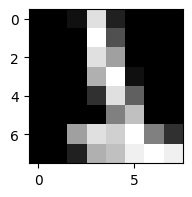

In [96]:
id_data_point = 1000

print("Label assigned to data point " + str(id_data_point) + ": " + str(soft_clusterer.labels_[id_data_point]))
print("Original target: " + str(target[id_data_point]))
plt.figure(figsize = (2,2))
plt.imshow(digits.images[id_data_point], cmap='gray')

print("Probability: ")
print(soft_clusterer.probabilities_[id_data_point])
print("Membership vector: ")
print(soft_membership[id_data_point])
print("Outlier score: ") # Higher -> more likely the point being an outlier
print(soft_clusterer.outlier_scores_[id_data_point])


In [97]:
# Define parameters for visualization
n_points = soft_membership.shape[0]
n_clusters = soft_membership.shape[1]
cols = 2
rows = int(np.ceil(n_clusters / cols))

n_points, n_clusters

(1797, 12)

In [98]:
# Define sharpen factor for visualization
sharpen_factor = 1.0

In [99]:
# Plot soft membership probabilities

def print_soft_membership(rows, cols, n_clusters, projection, sharpen_factor, soft_membership):
    fig, axes = plt.subplots(rows, cols, figsize=(8 * cols, 6 * rows))
    axes = np.array(axes).flatten()

    color_palette = sns.color_palette('Paired', n_clusters)

    for i in range(n_clusters):
        ax = axes[i]
        membership = min_max_scale(soft_membership[:, i])

        base = color_palette[i] if i < len(color_palette) else (0.5, 0.5, 0.5)
        colors = np.zeros((membership.size, 4))
        colors[:, :3] = base
        scaled_mb = min_max_scale(membership ** sharpen_factor)
        colors[:, 3] = scaled_mb

        sc = ax.scatter(*projection.T, s=40, linewidth=0, c=colors, edgecolors='none')
        ax.set_title(f'Cluster {i} membership')

    # Turn off unused subplots
    for j in range(n_clusters, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()


In [100]:
color_palette = sns.color_palette('Paired', n_clusters)

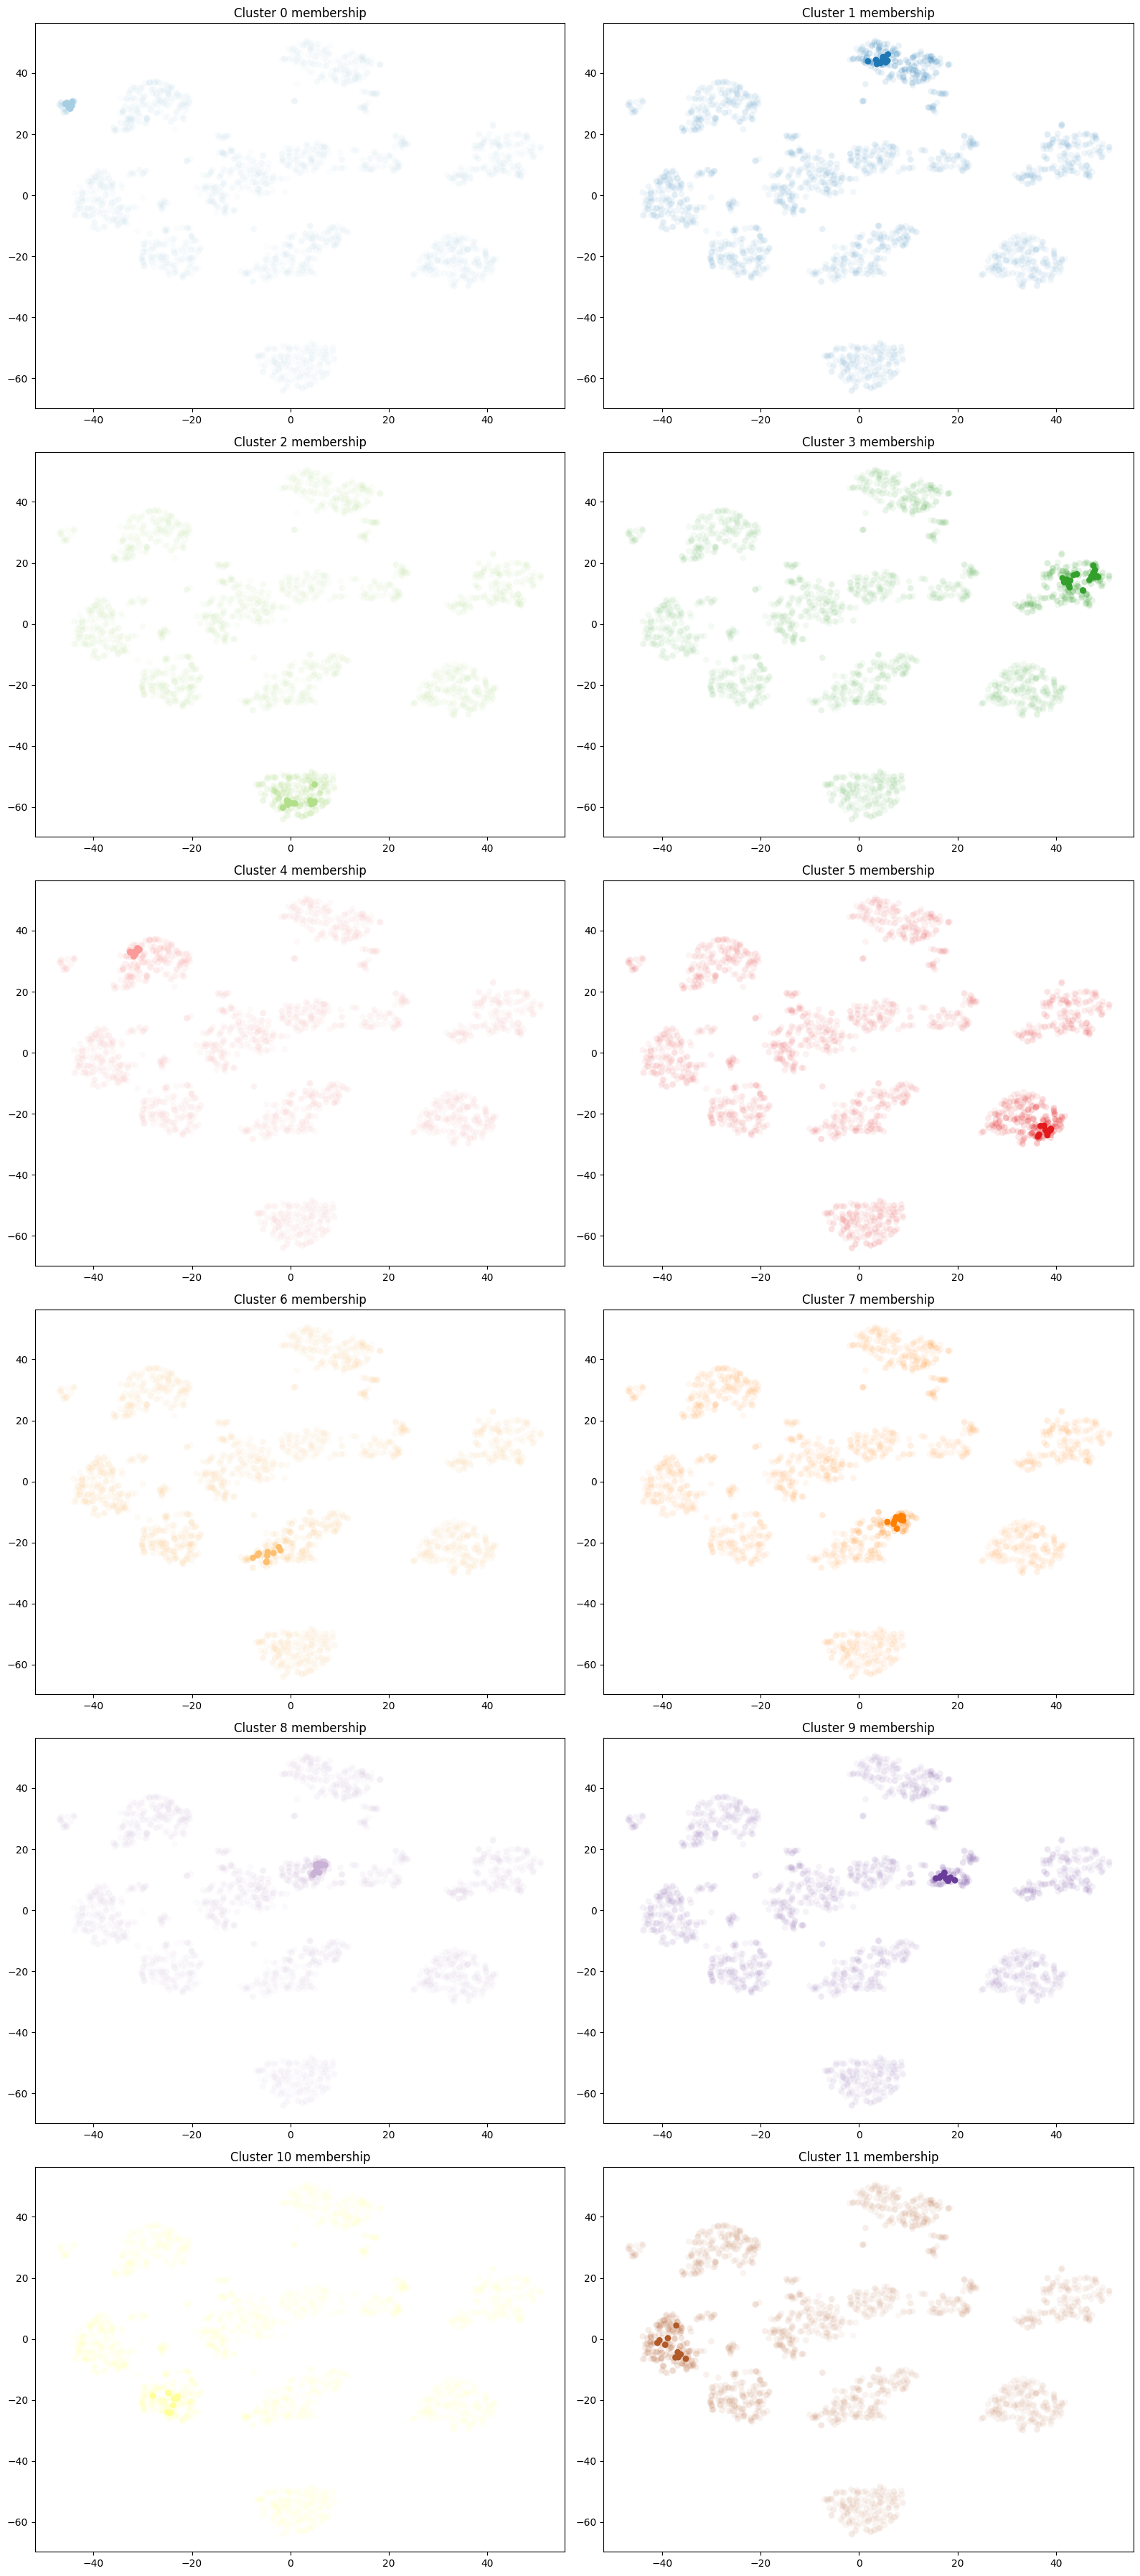

In [101]:
print_soft_membership(rows, cols, n_clusters, projection, sharpen_factor, soft_membership)

### Outlier Distribution

Detection of outliers that may be noticeably different from points in its local region.

https://hdbscan.readthedocs.io/en/latest/outlier_detection.html

C:\Users\zheng\AppData\Local\Temp\ipykernel_3184\329367501.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(soft_clusterer.outlier_scores_[np.isfinite(soft_clusterer.outlier_scores_)], rug=True)


<Axes: ylabel='Density'>

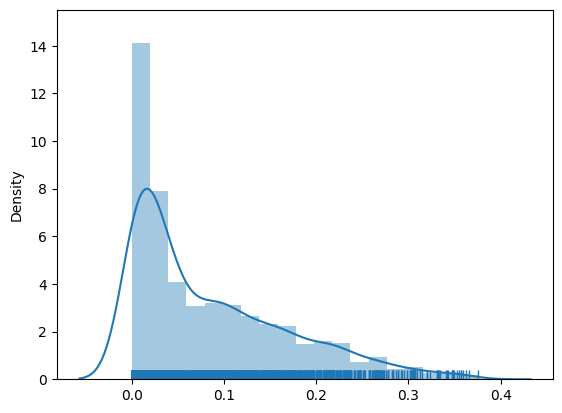

In [102]:
# Plot outlier score distribution
sns.distplot(soft_clusterer.outlier_scores_[np.isfinite(soft_clusterer.outlier_scores_)], rug=True)

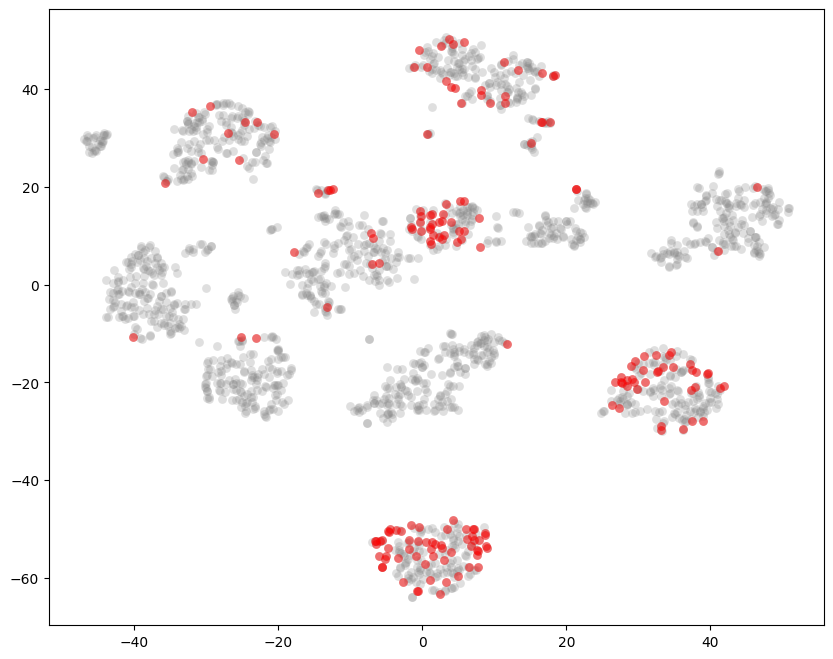

In [103]:
threshold = pd.Series(soft_clusterer.outlier_scores_).quantile(0.9)
outliers = np.where(soft_clusterer.outlier_scores_ > threshold)[0]
plt.figure(figsize=(10, 8))
plt.scatter(*projection.T, s=40, linewidth=0, c='gray', alpha=0.25)
plt.scatter(*projection[outliers].T, s=40, linewidth=0, c='red', alpha=0.5)

# Points at the edge of dense clusters could be highlighted, because they are far enough from the core


### Re-cluster according to membership vectors 

In [104]:
soft_avg = np.average(soft_membership)
print(soft_avg)

0.0699131570108127


In [105]:
soft_threshold = []
add_param = 0.02


for i in range(n_clusters):
    soft_threshold.append(float(np.average(soft_membership[:,i]))+add_param)

soft_threshold

[0.0816185432136879,
 0.0887982586362491,
 0.09587254364382457,
 0.09599310106577384,
 0.0859492812929615,
 0.09097538540179675,
 0.09207521108469698,
 0.08570094135028233,
 0.08924857762480114,
 0.08390316501123102,
 0.09391491906777112,
 0.09490795673667625]

In [106]:
new_labels = []
new_probabilities = []


for i in range(n_points):
    id_max_membership = np.argmax(soft_membership[i])
    if np.max(soft_membership[i]) > soft_threshold[id_max_membership]:
        new_labels.append(int(id_max_membership))
        new_probabilities.append(soft_membership[i][id_max_membership])
    else:
        new_labels.append(-1)
        new_probabilities.append(0)

In [107]:
print(new_labels)
print(len(new_labels))

[2, 8, -1, 11, 3, 10, 5, 1, -1, -1, 2, 9, 4, 11, 3, 7, -1, 1, -1, 10, 2, 9, 4, 11, 3, 7, -1, -1, -1, 10, 2, 10, 6, 6, 5, 7, 2, -1, 7, 10, -1, 3, 9, 1, 1, 11, -1, 9, 2, 2, -1, -1, 1, -1, -1, 2, 9, -1, 5, 11, 11, 1, 11, 11, 3, 5, 5, 5, 3, -1, 9, 6, 2, 10, -1, -1, 8, -1, 2, 2, 9, 1, 5, 11, 4, 9, -1, -1, 5, 11, 9, 11, 10, 8, 1, -1, 7, 3, 11, 8, 3, 2, 6, -1, -1, 10, -1, 9, 1, 7, 3, 3, 1, -1, 8, -1, -1, 7, 1, 10, -1, 3, 8, 8, 3, -1, 2, -1, 10, 8, 2, 9, 4, 11, 3, 7, 5, 1, -1, 10, 2, 9, 4, 11, 3, 7, 5, 1, -1, 10, 2, 9, -1, 11, 3, 7, 5, 1, 8, 10, 2, 10, 7, 7, 5, 7, 2, 10, -1, 10, 8, 8, 9, 1, 1, 11, 7, 9, 2, 2, 4, 4, 1, -1, 4, 2, 9, 4, 5, 11, 11, -1, 11, 11, -1, 5, 5, 5, 8, 10, 9, 7, 2, 10, 7, -1, -1, 4, 2, 2, 9, 1, 5, 11, 4, 9, 1, 11, 9, 11, 10, 9, 1, 5, -1, 3, 11, 9, 3, 2, 7, -1, 5, 10, 5, 9, 1, 7, 8, 3, 1, 4, 8, 4, 8, 7, 7, 9, 8, -1, 3, -1, 2, -1, 10, -1, 2, 8, 4, 11, 3, 6, 5, 1, -1, -1, 2, 9, 4, 11, 3, 7, 5, 1, -1, 1, 2, 9, 4, 11, 3, 6, 5, 1, -1, 10, 2, 10, 6, 6, 5, 6, 2, 10, -1, 10, -1, 3, 

In [108]:
# Count number of data points in each cluster
new_clust_dict = dict()

for i in new_labels:
    if int(i) in new_clust_dict:
        new_clust_dict[int(i)] += 1
    else:
        new_clust_dict[int(i)] = 1

In [109]:
new_clust_dict

{2: 171,
 8: 107,
 -1: 360,
 11: 156,
 3: 156,
 10: 132,
 5: 158,
 1: 152,
 9: 77,
 4: 126,
 7: 80,
 6: 92,
 0: 30}

In [110]:
count_diff = 0

for i in range(n_points):
    if new_labels[i] != hard_clusterer.labels_[i]:
        count_diff += 1
    
print(str(count_diff) + " points have been re-clustered")

552 points have been re-clustered


In [111]:
print(new_probabilities)

[np.float64(0.25788704807267443), np.float64(0.11092480297045276), 0, np.float64(0.19481121898915071), np.float64(0.10697946754370787), np.float64(0.10633703499408707), np.float64(0.11948443396724424), np.float64(0.1385051248440924), 0, 0, np.float64(0.12508882330355955), np.float64(1.0), np.float64(0.10343891257693748), np.float64(0.1880766996138664), np.float64(0.1607245485275762), np.float64(0.15610126053681309), 0, np.float64(0.1110120576377713), 0, np.float64(0.09821976536857399), np.float64(0.1473307582676865), np.float64(1.0), np.float64(0.12647242397615385), np.float64(0.1388226273741215), np.float64(0.10261343338066975), np.float64(0.1407490213391302), 0, 0, 0, np.float64(0.1022183573036224), np.float64(0.1416873263998012), np.float64(0.10751653995829541), np.float64(0.15383280574170335), np.float64(0.09381904226712698), np.float64(0.11794990891342974), np.float64(0.09244728657628871), np.float64(0.14956389432215006), 0, np.float64(0.08781641442361626), np.float64(0.1479789706

In [112]:
new_probabilities_norm = min_max_scale(np.array(new_probabilities))
print(new_probabilities_norm)

[0.25788705 0.1109248  0.         ... 0.         0.09849795 0.        ]


In [113]:
# Set colors for clusters
new_cluster_colors = [color_palette[x] if x >= 0
                  else (0.5, 0.5, 0.5)
                  for x in new_labels]
new_member_colors = [sns.desaturate(x, p) for x, p in zip(new_cluster_colors, new_probabilities_norm)]

In [114]:
new_colors = []

for i in range(len(new_cluster_colors)):
    new_colors.append(list(new_cluster_colors[i]))
    if(new_probabilities_norm[i] > 0):
        new_colors[i].append(new_probabilities_norm[i])
    else:
        new_colors[i].append(0.25)

new_colors
                     

[[0.6980392156862745,
  0.8745098039215686,
  0.5411764705882353,
  np.float64(0.25788704807267443)],
 [0.792156862745098,
  0.6980392156862745,
  0.8392156862745098,
  np.float64(0.11092480297045276)],
 [0.5, 0.5, 0.5, 0.25],
 [0.6941176470588235,
  0.34901960784313724,
  0.1568627450980392,
  np.float64(0.19481121898915071)],
 [0.2,
  0.6274509803921569,
  0.17254901960784313,
  np.float64(0.10697946754370787)],
 [1.0, 1.0, 0.6, np.float64(0.10633703499408707)],
 [0.8901960784313725,
  0.10196078431372549,
  0.10980392156862745,
  np.float64(0.11948443396724424)],
 [0.12156862745098039,
  0.47058823529411764,
  0.7058823529411765,
  np.float64(0.1385051248440924)],
 [0.5, 0.5, 0.5, 0.25],
 [0.5, 0.5, 0.5, 0.25],
 [0.6980392156862745,
  0.8745098039215686,
  0.5411764705882353,
  np.float64(0.12508882330355955)],
 [0.41568627450980394,
  0.23921568627450981,
  0.6039215686274509,
  np.float64(1.0)],
 [0.984313725490196, 0.6039215686274509, 0.6, np.float64(0.10343891257693748)],
 [0.69

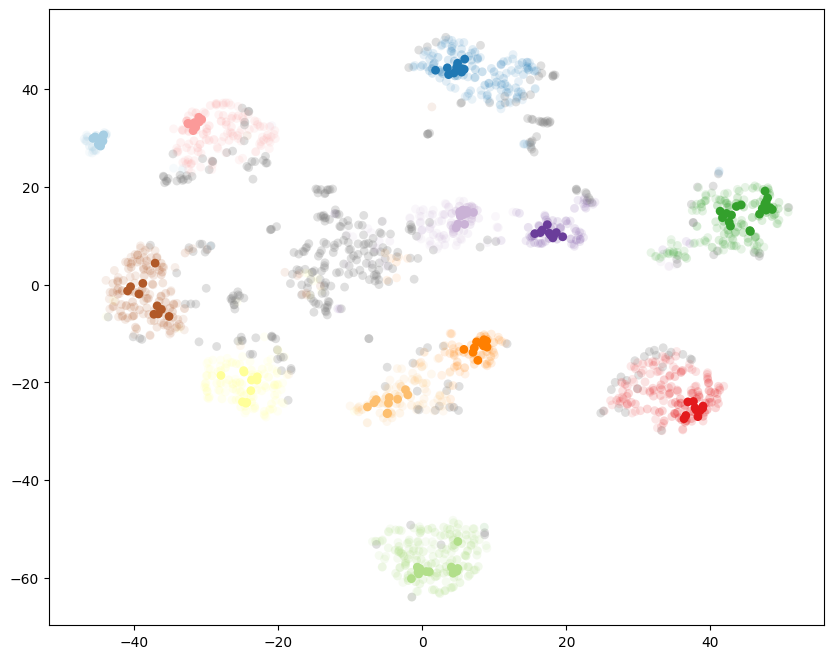

In [115]:
plt.figure(figsize=(10, 8))
plt.scatter(*projection.T, s=40, linewidth=0, c=new_colors, edgecolors='none')

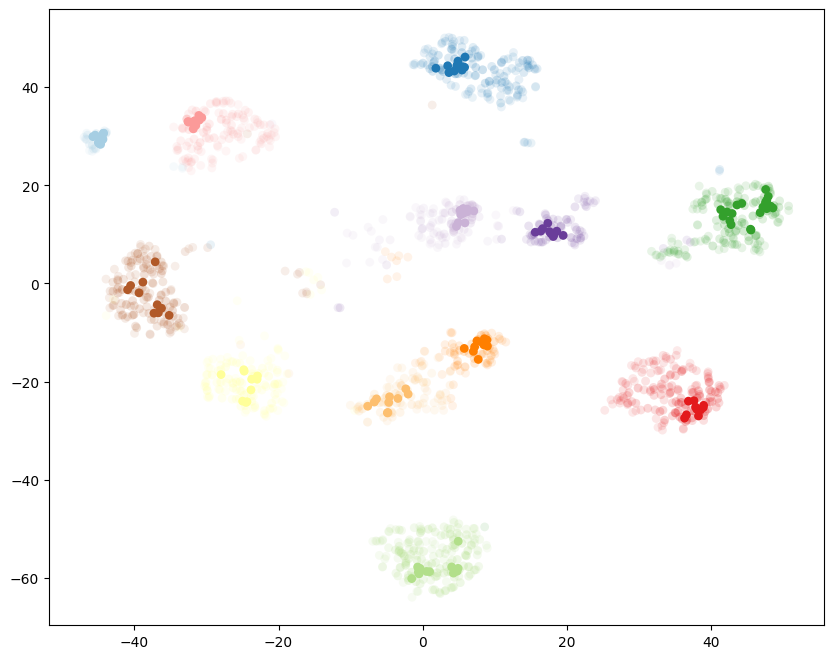

In [116]:
# Exclude noise points for better visualization
mask = np.array(new_labels) >= 0
proj_masked = projection[mask]
colors_masked = [c for c, m in zip(new_colors, mask) if m]
plt.figure(figsize=(10, 8))
plt.scatter(*proj_masked.T, s=40, linewidth=0, c=colors_masked, edgecolors='none')

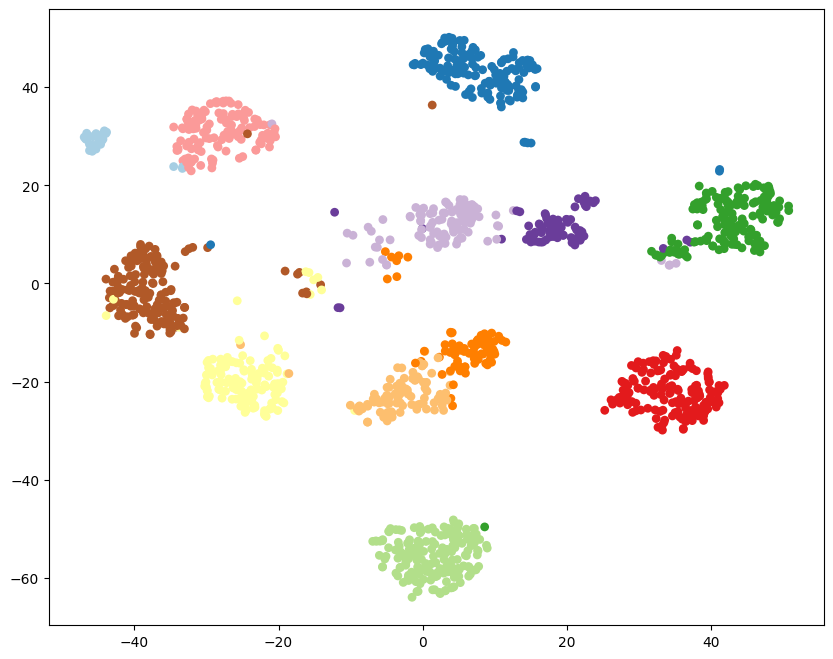

In [118]:
plt.figure(figsize=(10, 8))
plt.scatter(*proj_masked.T, s=40, linewidth=0, c=colors_masked, edgecolors='none', alpha=1)
# plt.savefig("images/new_clustering")

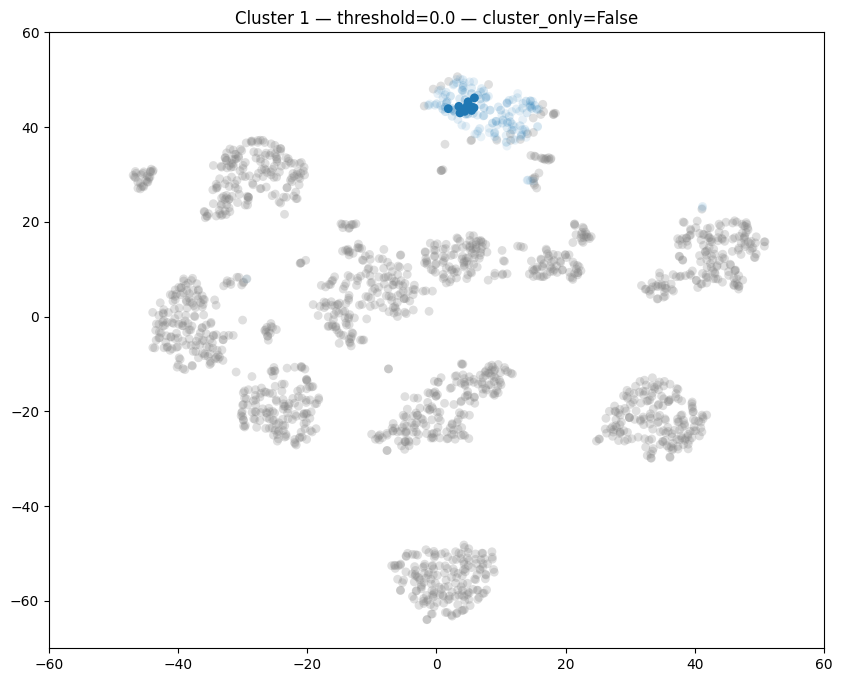

In [119]:
cluster_choice = 1   # label to visualize
membership_threshold = 0.0  # show only points with normalized probability > threshold
show_only_cluster = False  # if True, plot only chosen-cluster points

probs = new_probabilities_norm

base = hard_color_palette[cluster_choice] if (cluster_choice >= 0 and cluster_choice < len(hard_color_palette)) else (0.5, 0.5, 0.5)

labels_arr = np.array(new_labels, dtype=int)
mask_choice = labels_arr == int(cluster_choice)

n_points = projection.shape[0]
colors = np.zeros((n_points, 4))
colors[:, :3] = (0.5, 0.5, 0.5)  
colors[:, 3] = 0.25

if mask_choice.any():
    alphas = np.clip(probs, 0.0, 1.0)
    colors[mask_choice, :3] = base
    colors[mask_choice, 3] = np.clip(alphas[mask_choice], 0.05, 1.0)

if show_only_cluster:
    # When showing only the chosen cluster, handle noise (-1) specially
    if cluster_choice == -1:
        # show all points labeled as noise regardless of membership threshold
        plot_mask = mask_choice
    else:
        plot_mask = mask_choice & (probs > membership_threshold)
else:
    plot_mask = probs > membership_threshold

plt.figure(figsize=(10, 8))
plt.xlim(-60, 60)
plt.ylim(-70, 60)
if show_only_cluster:
    # Plot only chosen-cluster points (do not plot other points)
    if plot_mask.any():
        plt.scatter(projection[plot_mask, 0], projection[plot_mask, 1], c=colors[plot_mask], s=40, linewidths=0, edgecolors='none')
else:
    # Plot background (not-selected) and highlighted points
    plt.scatter(projection[~plot_mask, 0], projection[~plot_mask, 1], c=colors[~plot_mask], s=40, linewidths=0, edgecolors='none')
    plt.scatter(projection[plot_mask, 0], projection[plot_mask, 1], c=colors[plot_mask], s=40, linewidths=0, edgecolors='none')
plt.title(f'Cluster {cluster_choice} — threshold={membership_threshold} — cluster_only={show_only_cluster}')
plt.show()

In [120]:
# Imports for interactive plot
import plotly.graph_objects as go
from ipywidgets import Output, VBox
from IPython.display import clear_output

In [121]:
# Build interactive plot
n_points = projection.shape[0]
indices = np.arange(n_points)

colors = new_cluster_colors

# Build FigureWidget with index in customdata for lookup on click
fig = go.FigureWidget(
    data=go.Scattergl(
        x=projection[:,0],
        y=projection[:,1],
        mode='markers',
        marker=dict(size=8, color=[f'rgb({int(255*c[0])},{int(255*c[1])},{int(255*c[2])})' for c in colors]),
        customdata=indices,
        hovertemplate='index: %{customdata}<extra></extra>'
    ),
    layout=go.Layout(title='Interactive 2D projection of Digits dataset', width=1080, height=800)
)

out = Output()

def on_point_click(trace, points, selector):
    if len(points.point_inds) == 0:
        return
    i = points.point_inds[0]
    idx = int(trace.customdata[i])  # original index
    with out:
        clear_output(wait=True)
        fig_title = f'Point id: {idx}'

        plt.figure(figsize=(2,2))
        plt.imshow(digits.images[idx], cmap='gray')
        print("Original target:" + str(digits.target[idx]))
        print("Label from clustering:" + str(hard_clusterer.labels_[idx]))
        print("Label after re-clustering:" + str(new_labels[idx]))
        plt.title(fig_title)
        plt.axis('off')
        plt.show()


# Attach handler and display
scatter = fig.data[0]
scatter.on_click(on_point_click)

display(VBox([fig, out]))

    'data': [{'customdata': {'bdata': ('AAABAAIAAwAEAAUABgAHAAgACQAKAA' ... 'b6B…

## Analysis of a label subset

### Select a subset of k labels and consider only them


In [122]:
# Show occurrences in each cluster
soft_clust_dict

{2: 172,
 9: 18,
 -1: 839,
 5: 159,
 11: 70,
 3: 131,
 1: 136,
 4: 102,
 8: 68,
 6: 26,
 7: 19,
 10: 37,
 0: 20}

In [123]:
# Sort dictionary by label
sorted_soft_dict = dict(sorted(soft_clust_dict.items(), key=lambda item: item[0])) 

sorted_soft_dict

{-1: 839,
 0: 20,
 1: 136,
 2: 172,
 3: 131,
 4: 102,
 5: 159,
 6: 26,
 7: 19,
 8: 68,
 9: 18,
 10: 37,
 11: 70}

In [124]:
# Set the size of the subset considered
subset_labels = [1, 2, 11]

In [125]:
soft_membership

array([[0.05197322, 0.05729871, 0.25788705, ..., 0.05307688, 0.09052542,
        0.06473627],
       [0.0504084 , 0.04686046, 0.03663357, ..., 0.07497948, 0.04353457,
        0.04750335],
       [0.06348371, 0.06868785, 0.06470138, ..., 0.07300455, 0.06140918,
        0.06257285],
       ...,
       [0.06243469, 0.05723128, 0.06028778, ..., 0.06147589, 0.06085098,
        0.05998426],
       [0.05858826, 0.06040728, 0.08056707, ..., 0.07424964, 0.09849795,
        0.08092192],
       [0.06433618, 0.05451673, 0.06513587, ..., 0.05537234, 0.07567997,
        0.0726488 ]], shape=(1797, 12))

In [126]:
def build_subset_membership(subset_labels, membership):
    subset_membership = membership.copy()

    for i in range(subset_membership.shape[0]):
        for j in range(subset_membership.shape[1]):
            if j not in subset_labels:
                subset_membership[i][j] = 0 

    return subset_membership

In [127]:
subset_membership = build_subset_membership(subset_labels, soft_membership)

subset_membership

array([[0.        , 0.05729871, 0.25788705, ..., 0.        , 0.        ,
        0.06473627],
       [0.        , 0.04686046, 0.03663357, ..., 0.        , 0.        ,
        0.04750335],
       [0.        , 0.06868785, 0.06470138, ..., 0.        , 0.        ,
        0.06257285],
       ...,
       [0.        , 0.05723128, 0.06028778, ..., 0.        , 0.        ,
        0.05998426],
       [0.        , 0.06040728, 0.08056707, ..., 0.        , 0.        ,
        0.08092192],
       [0.        , 0.05451673, 0.06513587, ..., 0.        , 0.        ,
        0.0726488 ]], shape=(1797, 12))

In [128]:
# Import libraries for pie-charts
from matplotlib.patches import Wedge, Patch

In [129]:
lim = [-60, 60, -70, 60]

In [130]:
# Draw a small pie at each projection point showing subset_membership for subset_labels

def plot_projection_with_pies(projection, subset_membership, subset_labels, color_palette, lim, figsize=(12, 10), size_frac=0.02):
    """Plot a small pie at each 2D point in `projection`.

    - `subset_membership` should be an (n_points, n_clusters) membership matrix.
    - `subset_labels` is an iterable of cluster labels to show as slices in the pie.
    - `color_palette` is a sequence of RGB tuples (0..1) or matplotlib color specs.
    """
    fig, ax = plt.subplots(figsize=figsize)
    # radius (in data units) proportional to data span
    x_span = np.ptp(projection[:, 0]) if projection.shape[0] > 0 else 1.0
    y_span = np.ptp(projection[:, 1]) if projection.shape[0] > 0 else 1.0
    r = size_frac * max(x_span, y_span)

    cols = np.array(subset_labels, dtype=int)
    # prepare colors for subset labels (fall back to gray)
    n_pal = len(color_palette)
    colors = {lab: color_palette[int(lab) % n_pal] if int(lab) >= 0 else (0.5, 0.5, 0.5) for lab in cols}

    for i, (x, y) in enumerate(projection):
        vals = np.array(subset_membership[i])
        sel = vals[cols]
        total = float(sel.sum())
        if total <= 0:
            # draw a small gray dot if no membership in subset
            ax.scatter(x, y, color='lightgray', s=(r * 1000), linewidths=0, zorder=1)
            continue
        start = 0.0
        for lab, v in zip(cols, sel):
            if v <= 0:
                continue
            theta1 = 360.0 * start
            theta2 = 360.0 * (start + v / total)
            wedge = Wedge((x, y), r, theta1, theta2, facecolor=colors[int(lab)], edgecolor='none', linewidth=0, zorder=2)
            ax.add_patch(wedge)
            start += v / total

    # Legend for subset labels
    legend_handles = [Patch(facecolor=colors[int(l)], label=f'Cluster {l}') for l in cols]
    ax.legend(handles=legend_handles, bbox_to_anchor=(1.02, 1), loc='upper left')
    ax.set_aspect('equal', adjustable='datalim')
    ax.set_xlabel('TSNE-1')
    ax.set_ylabel('TSNE-2')
    ax.set_title('Projection — pie per point (subset membership)')
    plt.xlim(lim[0], lim[1])
    plt.ylim(lim[2], lim[3])
    plt.tight_layout()
    return fig, ax


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


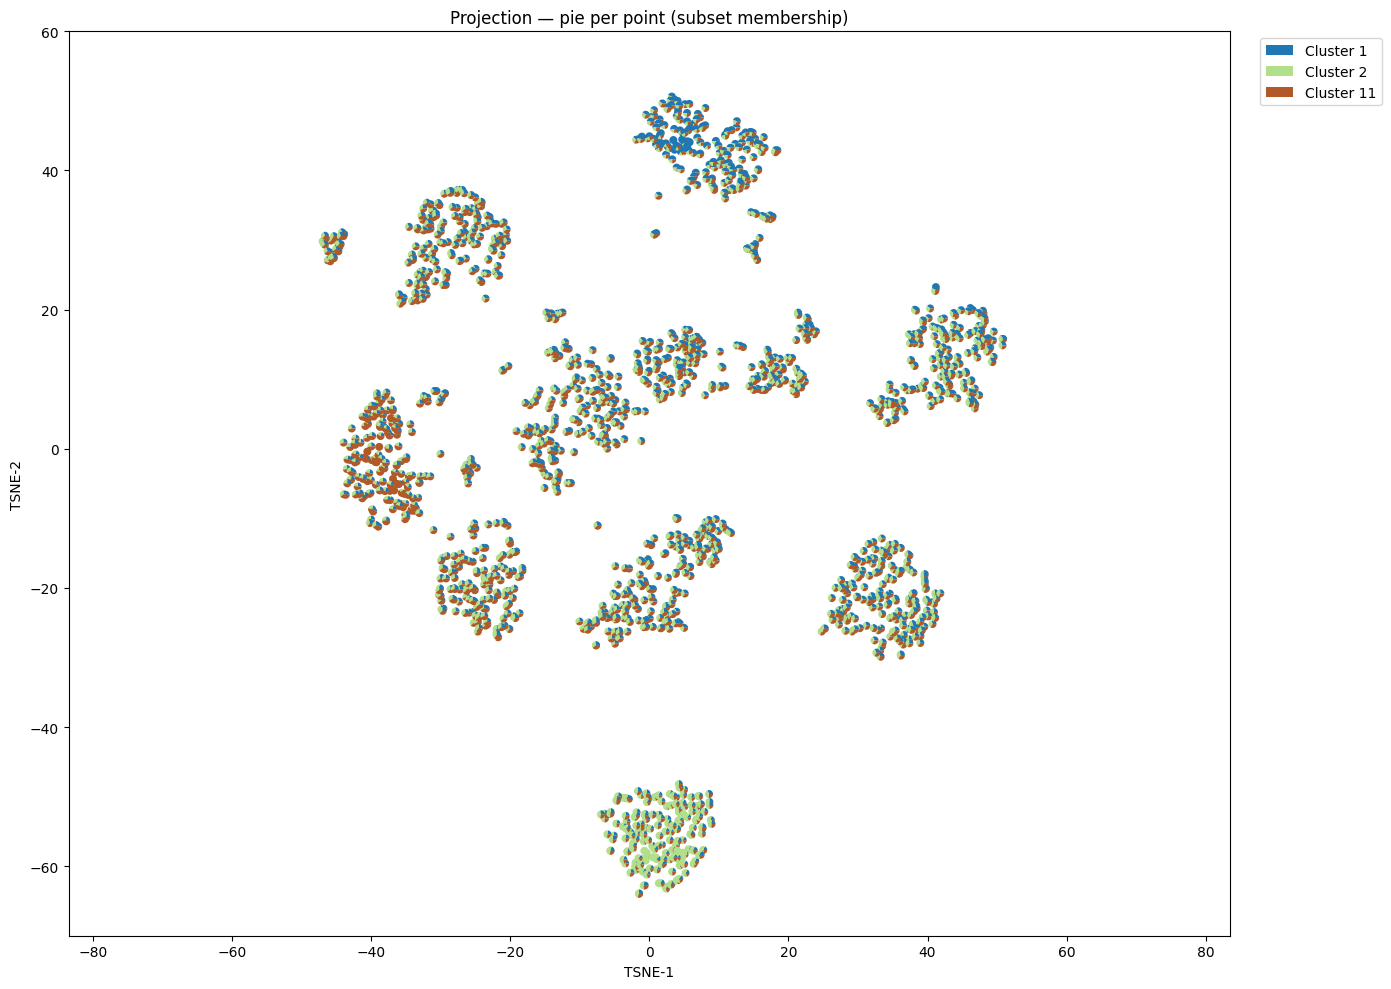

In [131]:
# Plot the piecharts
fig, ax = plot_projection_with_pies(projection, subset_membership, subset_labels, hard_color_palette, lim, figsize=(14,10), size_frac=0.005)
plt.show()

In [132]:
def build_residual_membership(subset_labels, membership):
    residual_membership = membership.copy()
    residual_arr = []

    for i in range(residual_membership.shape[0]):
        temp = 0
        for j in range(residual_membership.shape[1]):
            if j not in subset_labels:
                temp += residual_membership[i][j]
                residual_membership[i][j] = 0

        residual_arr.append(np.append(residual_membership[i], temp))
        

    return np.array(residual_arr)

In [133]:
residual_membership = build_residual_membership(subset_labels, soft_membership)

residual_membership

array([[0.        , 0.05729871, 0.25788705, ..., 0.        , 0.06473627,
        0.5781544 ],
       [0.        , 0.04686046, 0.03663357, ..., 0.        , 0.04750335,
        0.5102179 ],
       [0.        , 0.06868785, 0.06470138, ..., 0.        , 0.06257285,
        0.57768007],
       ...,
       [0.        , 0.05723128, 0.06028778, ..., 0.        , 0.05998426,
        0.57074166],
       [0.        , 0.06040728, 0.08056707, ..., 0.        , 0.08092192,
        0.60956204],
       [0.        , 0.05451673, 0.06513587, ..., 0.        , 0.0726488 ,
        0.57106864]], shape=(1797, 13))

In [134]:
residual_labels = [1,2,11,12]

print(residual_labels)

[1, 2, 11, 12]


In [135]:
# Plot the piecharts
fig, ax = plot_projection_with_pies(projection, residual_membership, residual_labels, hard_color_palette, figsize=(14,10), size_frac=0.005)
plt.show()

TypeError: plot_projection_with_pies() missing 1 required positional argument: 'lim'

### Keep the highest k probabilities for each point

In [136]:
def keep_highest_k_prob(k, membership):
    highest_membership = membership.copy()
    for i in range(highest_membership.shape[0]):
        temp = np.argpartition(-highest_membership[i], k)
        topK = temp[:k]

        for j in range(highest_membership.shape[1]):
            if j not in topK:
                highest_membership[i][j] = 0
    
    return highest_membership


In [137]:
defined_k = 3
highest_membership = keep_highest_k_prob(defined_k, soft_membership)

highest_membership

array([[0.        , 0.        , 0.25788705, ..., 0.        , 0.09052542,
        0.        ],
       [0.0504084 , 0.        , 0.        , ..., 0.07497948, 0.        ,
        0.        ],
       [0.        , 0.06868785, 0.        , ..., 0.07300455, 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.08056707, ..., 0.        , 0.09849795,
        0.08092192],
       [0.        , 0.        , 0.        , ..., 0.        , 0.07567997,
        0.0726488 ]], shape=(1797, 12))

In [ ]:
full_labels = list(range(soft_membership.shape[1]))

full_labels

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


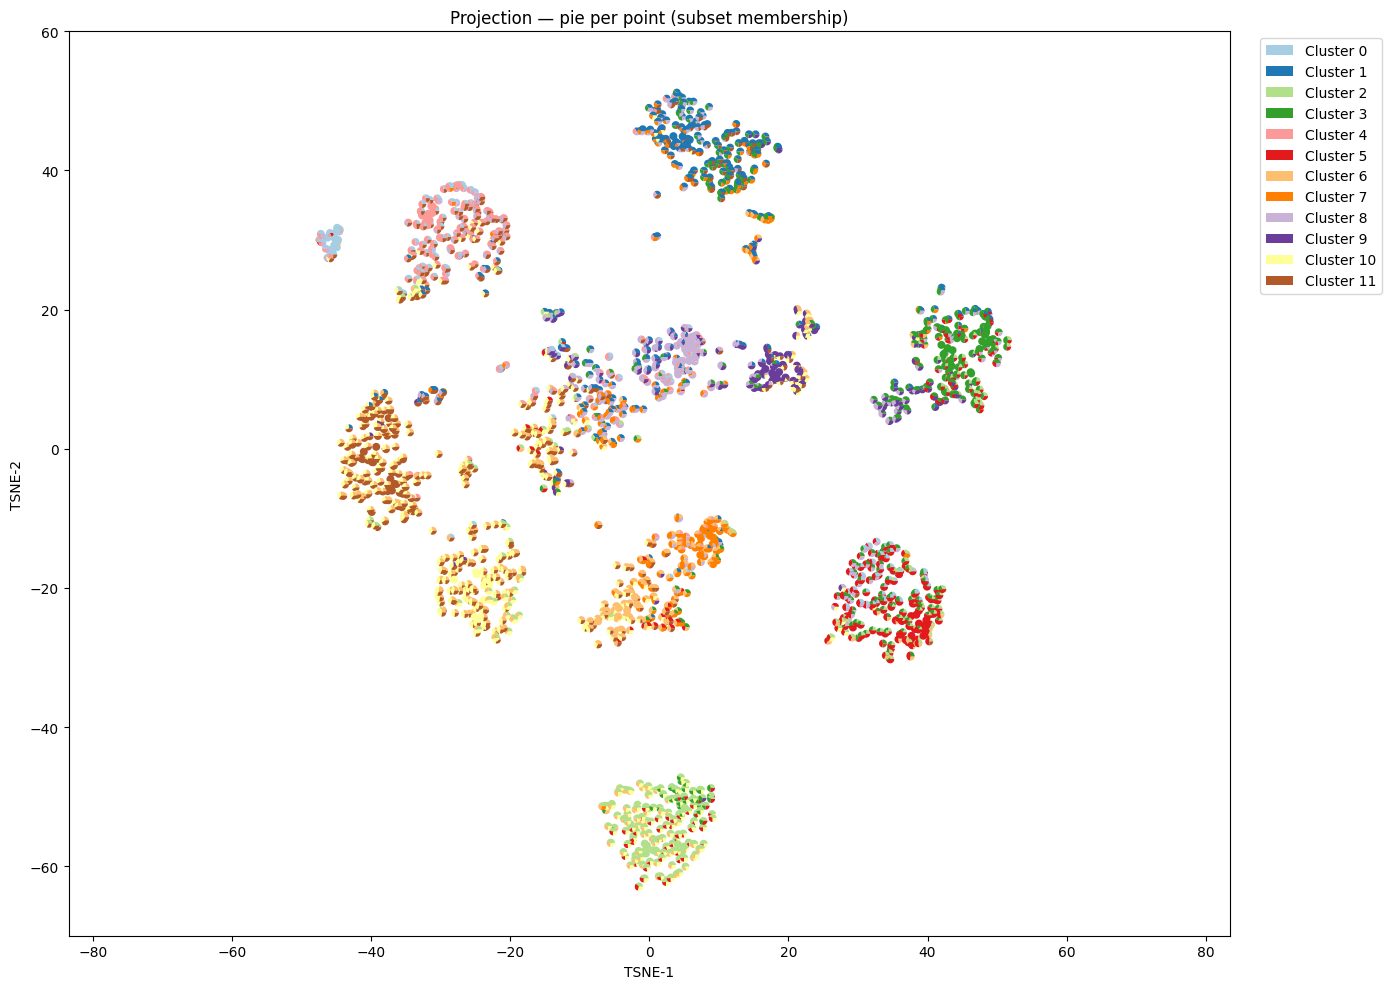

In [ ]:
# Plot the piecharts
fig, ax = plot_projection_with_pies(projection, highest_membership, full_labels, hard_color_palette, figsize=(14,10), size_frac=0.005)
plt.show()

In [ ]:
def keep_k_with_residual(k, membership):
    highest_membership = membership.copy()
    residual_arr = []

    for i in range(highest_membership.shape[0]):
        temp = np.argpartition(-highest_membership[i], k)
        topK = temp[:k]
        temp_sum = 0

        for j in range(highest_membership.shape[1]):
            if j not in topK:
                temp_sum += highest_membership[i][j]
                highest_membership[i][j] = 0

        residual_arr.append(np.append(highest_membership[i], temp_sum))
    
    return np.array(residual_arr)

In [ ]:
k_residual_membership = keep_k_with_residual(defined_k, soft_membership)

In [ ]:
full_res_labels = list(range(soft_membership.shape[1]))
full_res_labels.append(12)

print(full_res_labels)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


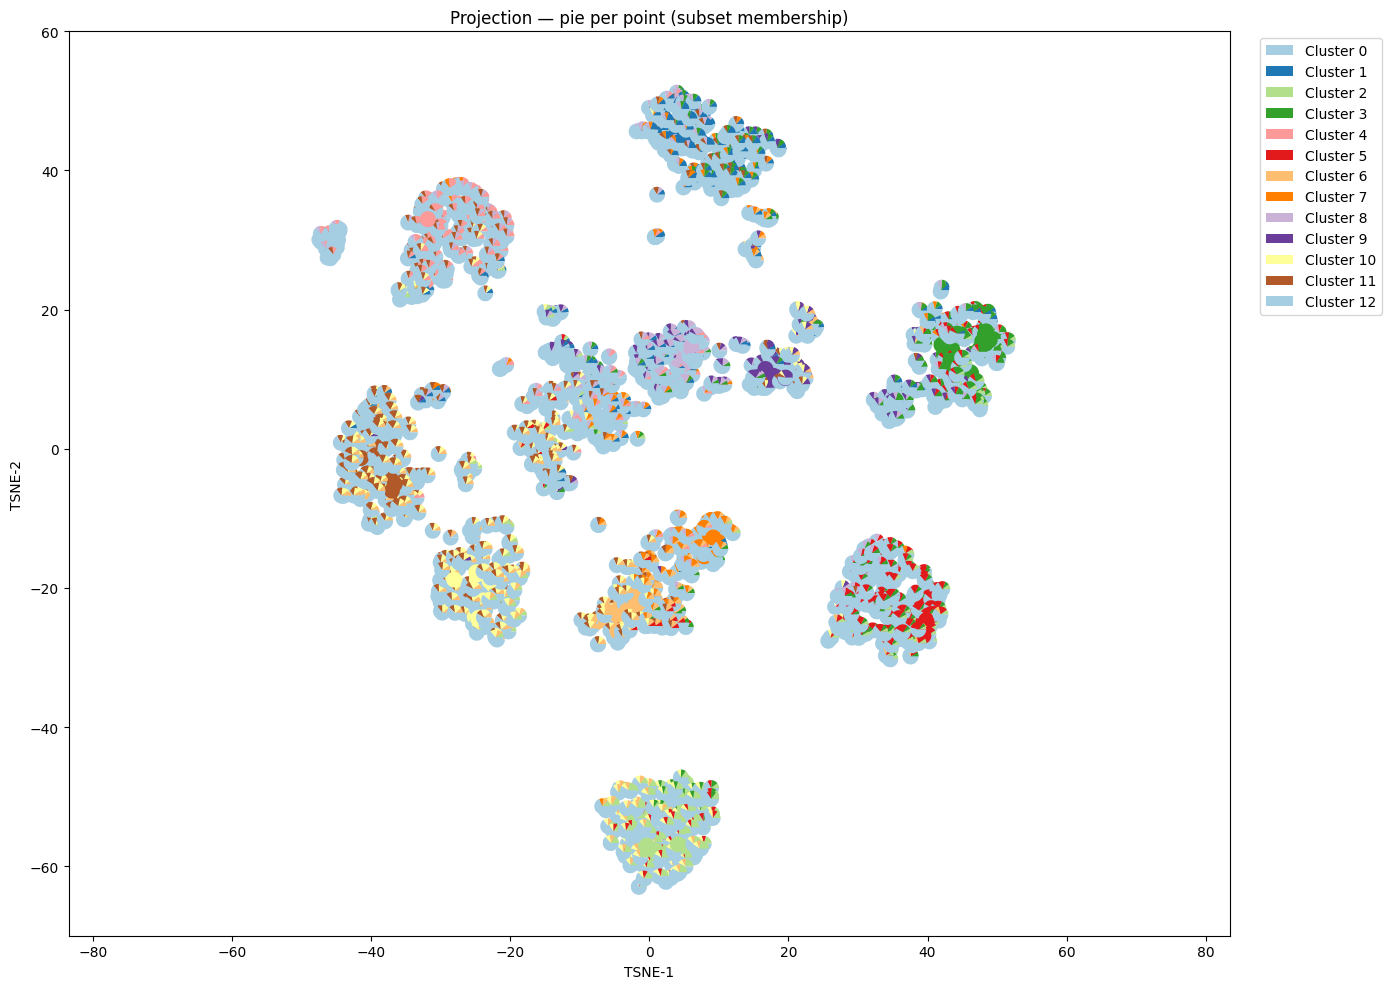

In [ ]:
# Plot the piecharts
fig, ax = plot_projection_with_pies(projection, k_residual_membership, full_res_labels, hard_color_palette, figsize=(14,10), size_frac=0.01)
plt.show()

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


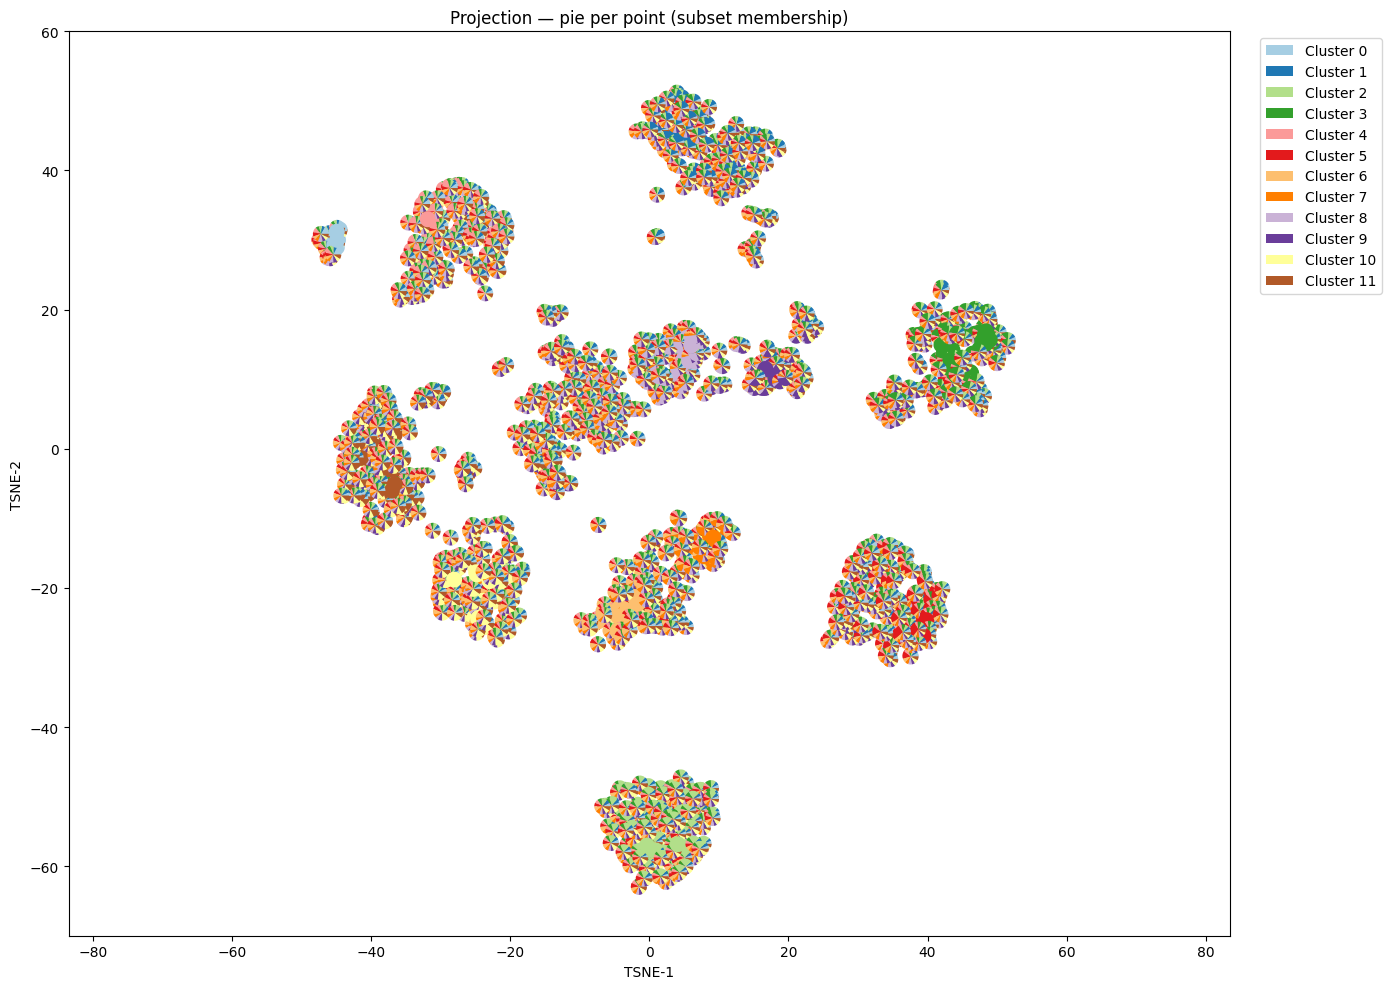

In [ ]:
# Plot the piecharts
fig, ax = plot_projection_with_pies(projection, soft_membership, full_labels, hard_color_palette, figsize=(14,10), size_frac=0.01)
plt.show()

In [233]:
# Interactive projection + large pie on click
# Shows a big pie for the clicked point's membership vector (uses subset_membership if present)
from ipywidgets import HBox, VBox, Output, Layout
import matplotlib.colors as mcolors
from IPython.display import display, HTML

# Choose membership matrix and labels
membership = residual_membership

labels = residual_labels

palette = hard_color_palette

label_colors = [mcolors.to_hex(palette[int(l) % len(palette)]) for l in labels]

# Build scatter FigureWidget
n_points = projection.shape[0]
indices = list(range(n_points))
scatter = go.FigureWidget(
    data=go.Scattergl(
        x=projection[:, 0],
        y=projection[:, 1],
        mode='markers',
        marker=dict(size=6, color='lightgray'),
        customdata=indices,
        hovertemplate='index: %{customdata}<extra></extra>'
    ),
    layout=go.Layout(title='Click a point to show membership pie', width=900, height=700)
)

# Pre-build pie FigureWidget (empty)
pie_fig = go.FigureWidget(layout=go.Layout(title='Membership (click a point)', width=450, height=450))
pie_fig.add_trace(go.Pie(labels=[f'Cluster {l}' for l in labels], values=[0]*len(labels), marker=dict(colors=label_colors)))

info_out = Output()

# Click handler updates the pie chart and information panel
def on_point_click(trace, points, selector):
    if len(points.point_inds) == 0:
        return
    i = points.point_inds[0]
    idx = int(trace.customdata[i])
    vals = membership[idx]
    sel_vals = [float(vals[int(l)]) for l in labels]
    total = sum(sel_vals)

    with info_out:
        info_out.clear_output()
        if total <= 0:
            display(HTML(f"<b>Point {idx}</b><br>No membership in selected labels"))
        else:
            pie_fig.data[0].values = sel_vals
            pie_fig.layout.title = f'Point {idx} — membership pie (sum={total:.3f})'
            # display(HTML(f"<b>Point {idx}</b><br>Label (hard): {int(hard_clusterer.labels_[idx]) if 'hard_clusterer' in globals() else 'n/a'}<br>Label (new): {int(new_labels[idx]) if 'new_labels' in globals() else 'n/a'}"))

            # plt.figure(figsize=(2,2))
            # plt.imshow(digits.images[idx], cmap='gray')
            print("Original target:" + str(digits.target[idx]))
            print("Label from clustering:" + str(hard_clusterer.labels_[idx]))
            print("Label after re-clustering:" + str(new_labels[idx]))

# Attach handler
scatter.data[0].on_click(on_point_click)

# Display side-by-side: scatter | (pie + info)
right_col = VBox([pie_fig, info_out], layout=Layout(width='480px'))
display(HBox([scatter, right_col]))


    'data': [{'customdata': [0, 1, 2, ..., 1794, 1795, 1796],
              'hov…

## Experiments with reduced digits set

In [139]:
digits = datasets.load_digits()

digits

{'data': array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ..., 10.,  0.,  0.],
        [ 0.,  0.,  0., ..., 16.,  9.,  0.],
        ...,
        [ 0.,  0.,  1., ...,  6.,  0.,  0.],
        [ 0.,  0.,  2., ..., 12.,  0.,  0.],
        [ 0.,  0., 10., ..., 12.,  1.,  0.]], shape=(1797, 64)),
 'target': array([0, 1, 2, ..., 8, 9, 8], shape=(1797,)),
 'frame': None,
 'feature_names': ['pixel_0_0',
  'pixel_0_1',
  'pixel_0_2',
  'pixel_0_3',
  'pixel_0_4',
  'pixel_0_5',
  'pixel_0_6',
  'pixel_0_7',
  'pixel_1_0',
  'pixel_1_1',
  'pixel_1_2',
  'pixel_1_3',
  'pixel_1_4',
  'pixel_1_5',
  'pixel_1_6',
  'pixel_1_7',
  'pixel_2_0',
  'pixel_2_1',
  'pixel_2_2',
  'pixel_2_3',
  'pixel_2_4',
  'pixel_2_5',
  'pixel_2_6',
  'pixel_2_7',
  'pixel_3_0',
  'pixel_3_1',
  'pixel_3_2',
  'pixel_3_3',
  'pixel_3_4',
  'pixel_3_5',
  'pixel_3_6',
  'pixel_3_7',
  'pixel_4_0',
  'pixel_4_1',
  'pixel_4_2',
  'pixel_4_3',
  'pixel_4_4',
  'pixel_4_5',
  'pixel_4_6',
  'pixel_4_7'

In [240]:
chosen_targets = [2, 3, 7, 8]

In [241]:
reduced_digits = []
reduced_targets = []

for i in range(len(digits.data)):
    if digits.target[i] in chosen_targets:
        reduced_digits.append(digits.data[i])
        reduced_targets.append(int(digits.target[i]))

In [143]:
print(len(reduced_digits))
print(len(reduced_targets))

713
713


In [144]:
reduced_digits = np.array(reduced_digits)

reduced_digits

array([[ 0.,  0.,  0., ..., 16.,  9.,  0.],
       [ 0.,  0.,  7., ...,  9.,  0.,  0.],
       [ 0.,  0.,  7., ...,  0.,  0.,  0.],
       ...,
       [ 0.,  0.,  5., ...,  3.,  0.,  0.],
       [ 0.,  0.,  1., ...,  6.,  0.,  0.],
       [ 0.,  0., 10., ..., 12.,  1.,  0.]], shape=(713, 64))

In [145]:
# Project data into two dimensions to visualize via t-SNE
reduced_projection = TSNE().fit_transform(reduced_digits)

reduced_projection

array([[-12.484621  ,  18.241543  ],
       [ -9.715645  , -20.275347  ],
       [ 38.481297  ,  10.234541  ],
       ...,
       [  0.34737688,  14.794168  ],
       [ -0.61505014,  13.573079  ],
       [ -2.3171687 ,   8.966853  ]], shape=(713, 2), dtype=float32)

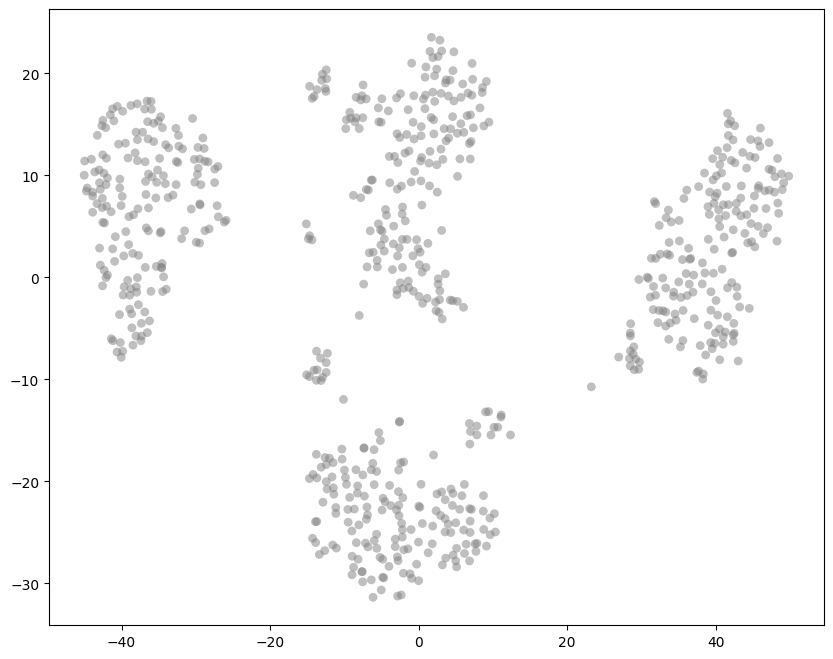

In [146]:
# Plot data in 2-dimensional space
# Plotting arguments: s = marker size, c = color (RGBA array), alpha = transparency
plt.figure(figsize=(10, 8))
plt.scatter(*reduced_projection.T, s=40, linewidth=0, color=[0.5, 0.5, 0.5], alpha=0.5, edgecolors='none')

### Hard Clustering

In [239]:
# Hard Clustering
r_hard_clusterer = hdbscan.HDBSCAN(min_cluster_size=10, prediction_data=False).fit(reduced_digits)

d:\Projects\Thesis\PoliTopic\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

d:\Projects\Thesis\PoliTopic\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



In [238]:
# Count number of data points in each cluster
r_hard_clust_dict = dict()

for i in r_hard_clusterer.labels_:
    if int(i) in r_hard_clust_dict:
        r_hard_clust_dict[int(i)] += 1
    else:
        r_hard_clust_dict[int(i)] = 1

In [149]:
# Show how many clusters are found: -1 represents noise cluster
len(r_hard_clust_dict.keys())

5

In [150]:
# Show occurrences in each cluster
r_hard_clust_dict

{-1: 300, 1: 120, 0: 145, 2: 102, 3: 46}

In [151]:
# Sort dictionary by label
r_sorted_hard_dict = dict(sorted(r_hard_clust_dict.items(), key=lambda item: item[0])) 

r_sorted_hard_dict

{-1: 300, 0: 145, 1: 120, 2: 102, 3: 46}

In [152]:
# Set colors for hard clusters
r_hard_color_palette = sns.color_palette('tab10', len(r_hard_clust_dict.keys())-1)
r_hard_cluster_colors = [r_hard_color_palette[x] if x >= 0
                  else (0.5, 0.5, 0.5)
                  for x in r_hard_clusterer.labels_]
r_hard_member_colors = [sns.desaturate(x, p) for x, p in
                         zip(r_hard_cluster_colors, r_hard_clusterer.probabilities_)]

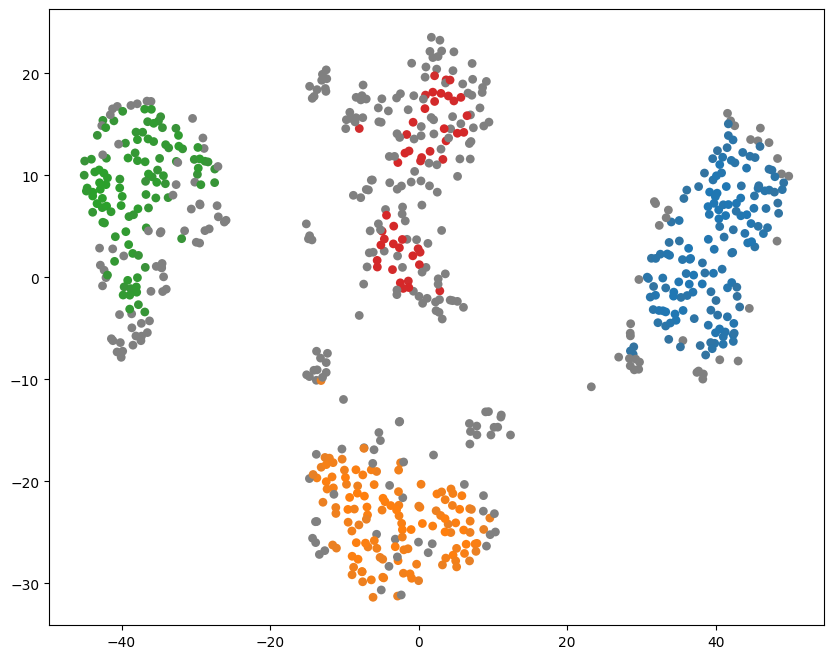

In [153]:
# Plot hard clustering results
plt.figure(figsize=(10, 8))
plt.scatter(*reduced_projection.T, s=40, linewidth=0, c=r_hard_member_colors, edgecolors='none')
# plt.savefig("images/hard_clustering_2378")

In [236]:
reduced_projection_orig = []

for i in range(len(data)):
    if digits.target[i] in chosen_targets:
        reduced_projection_orig.append(projection[i])

reduced_projection_orig = np.array(reduced_projection_orig)

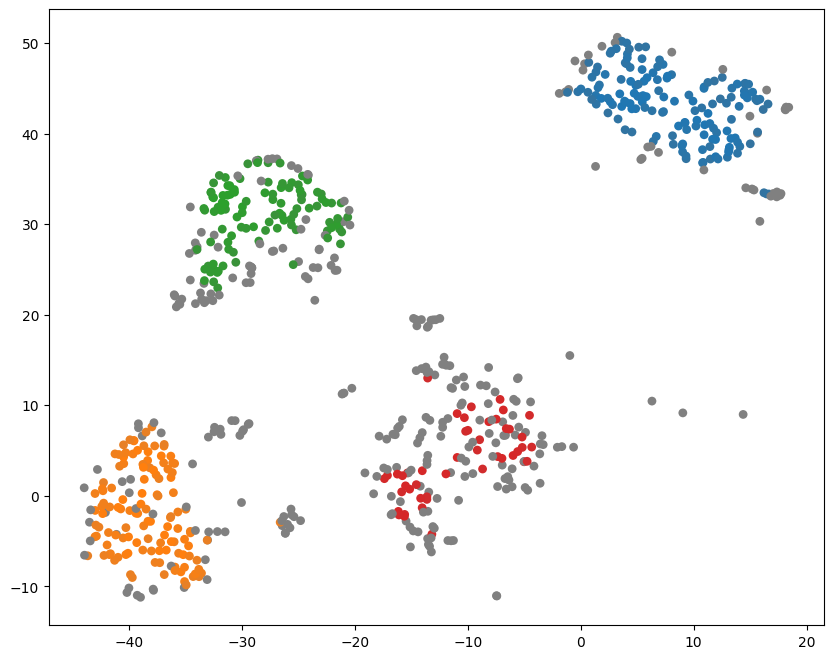

In [155]:
# Plot hard clustering results
plt.figure(figsize=(10, 8))
plt.scatter(*reduced_projection_orig.T, s=40, linewidth=0, c=r_hard_member_colors, edgecolors='none')
#plt.savefig("images/hard_clustering_2378_orig")

In [ ]:
# # Build interactive plot

# plt.figure(figsize=(10, 8))
# plt.scatter(*reduced_projection_orig.T, s=40, linewidth=0, c=r_hard_member_colors, edgecolors='none')

n_points = reduced_projection_orig.shape[0]
indices = np.arange(n_points)

colors = r_hard_member_colors

# Build FigureWidget with index in customdata for lookup on click
fig = go.FigureWidget(
    data=go.Scattergl(
        x=reduced_projection_orig[:,0],
        y=reduced_projection_orig[:,1],
        mode='markers',
        marker=dict(size=8, color=[f'rgb({int(255*c[0])},{int(255*c[1])},{int(255*c[2])})' for c in colors]),
        customdata=indices,
        hovertemplate='index: %{customdata}<extra></extra>'
    ),
    layout=go.Layout(title='Interactive 2D projection of Digits dataset', width=1080, height=800)
)

out = Output()

def on_point_click(trace, points, selector):
    if len(points.point_inds) == 0:
        return
    i = points.point_inds[0]
    idx = int(trace.customdata[i])  # original index
    with out:
        clear_output(wait=True)
        fig_title = f'Point id: {idx}'

        plt.figure(figsize=(2,2))
        plt.imshow(digits.images[idx], cmap='gray')
        print("Original target:" + str(reduced_targets[idx]))
        print("Label from clustering:" + str(hard_clusterer.labels_[idx]))
        print("Label after re-clustering:" + str(new_labels[idx]))
        plt.title(fig_title)
        plt.axis('off')
        plt.show()


# Attach handler and display
scatter = fig.data[0]
scatter.on_click(on_point_click)

display(VBox([fig, out]))

    'data': [{'customdata': {'bdata': ('AAABAAIAAwAEAAUABgAHAAgACQAKAA' ... 'K/A…

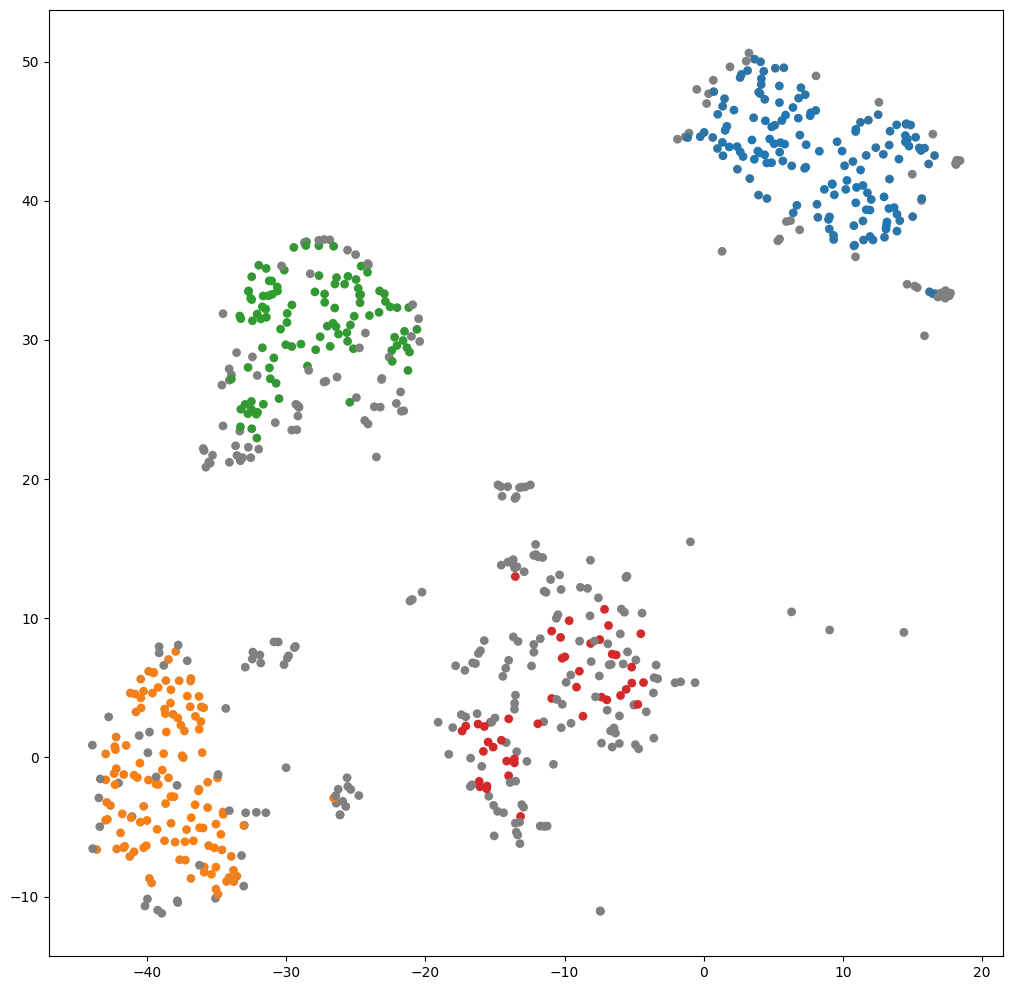

In [212]:
fig, ax = plt.subplots(figsize=(14, 10))

# Plot the scatter points
ax.scatter(*reduced_projection_orig.T, s=40, linewidth=0, c=r_hard_member_colors, edgecolors='none')

# Force the exact same aspect ratio as the pie plot
ax.set_aspect('equal', adjustable='box')

# Apply the exact same axis limits (r_lim) used in the pie plot
ax.set_xlim(r_lim[0], r_lim[1])
ax.set_ylim(r_lim[2], r_lim[3])

plt.tight_layout()
plt.savefig('images/hard_clustering_2378', bbox_inches='tight', pad_inches=0.1)
plt.show()

### Soft Clustering

In [156]:
# Soft Clustering
r_soft_clusterer = hdbscan.HDBSCAN(min_cluster_size=10, prediction_data=True).fit(reduced_digits)

d:\Projects\Thesis\PoliTopic\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

d:\Projects\Thesis\PoliTopic\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



In [157]:
# Show soft membership vectors
r_soft_membership = all_points_membership_vectors(r_soft_clusterer)

r_soft_membership

array([[0.16085316, 0.14653307, 0.15690151, 0.20437913],
       [0.11810099, 0.44249786, 0.16047051, 0.16599617],
       [0.29582922, 0.14577476, 0.12874363, 0.15605419],
       ...,
       [0.14208885, 0.1497696 , 0.15601151, 0.23834143],
       [0.13540341, 0.14071485, 0.15869936, 0.30849791],
       [0.12229902, 0.16297524, 0.1534016 , 0.22918876]], shape=(713, 4))

In [158]:
# Define parameters for visualization
r_n_points = r_soft_membership.shape[0]
r_n_clusters = r_soft_membership.shape[1]
r_cols = 2
r_rows = int(np.ceil(r_n_clusters / r_cols))

r_n_points, r_n_clusters

(713, 4)

In [159]:
# print_soft_membership(r_rows, r_cols, r_n_clusters, reduced_projection_orig, sharpen_factor, r_soft_membership)

In [160]:
r_soft_avg = np.average(r_soft_membership)
print(r_soft_avg)

0.20243596810117467


In [161]:
r_soft_threshold = []
r_add_param = 0.01


for i in range(r_n_clusters):
    r_soft_threshold.append(float(np.average(r_soft_membership[:,i]))+r_add_param)

r_soft_threshold

[0.2049213528781584,
 0.2243291783073253,
 0.19346642889469554,
 0.22702691232451946]

In [162]:
r_new_labels = []
r_new_probabilities = []


for i in range(r_n_points):
    r_id_max_membership = np.argmax(r_soft_membership[i])
    if np.max(r_soft_membership[i]) > r_soft_threshold[r_id_max_membership]:
        r_new_labels.append(int(r_id_max_membership))
        r_new_probabilities.append(r_soft_membership[i][r_id_max_membership])
    else:
        r_new_labels.append(-1)
        r_new_probabilities.append(0)

In [163]:
# Count number of data points in each cluster
r_new_clust_dict = dict()

for i in r_new_labels:
    if int(i) in r_new_clust_dict:
        r_new_clust_dict[int(i)] += 1
    else:
        r_new_clust_dict[int(i)] = 1

In [164]:
r_count_diff = 0

for i in range(r_n_points):
    if r_new_labels[i] != r_hard_clusterer.labels_[i]:
        r_count_diff += 1
    
print(str(r_count_diff) + " points have been re-clustered")

166 points have been re-clustered


In [165]:
r_new_probabilities_norm = min_max_scale(np.array(r_new_probabilities))
print(r_new_probabilities_norm)

[0.         0.44249786 0.29582922 0.28188738 0.29656928 0.43147651
 0.28583813 0.27360036 0.31667715 0.3251187  0.21159591 0.27181005
 0.         1.         0.28050024 0.41261652 0.32694314 0.
 0.         0.31342529 0.         0.         0.         0.3572579
 0.40237027 0.27587005 0.41349711 0.40988759 0.         0.42065109
 0.         1.         0.35994323 0.34528782 0.22415352 0.36680567
 0.34980006 0.43875721 0.25450433 0.331049   0.         0.30261504
 0.45708611 0.         0.40634048 0.         0.         0.35339647
 0.29067017 0.25375223 0.         0.         0.35406576 0.27130186
 0.39500328 0.29868015 0.         0.36715305 0.30846171 1.
 0.         0.3425272  0.34104872 0.25442327 0.3782355  0.2320044
 0.35023678 0.37775941 1.         0.32406594 0.29696374 0.43991809
 1.         0.3157032  0.36087961 0.33784097 0.28906141 0.
 0.26008511 0.40352682 0.         0.         0.279384   0.21376675
 0.40710854 0.32255569 0.26073493 0.30568252 0.45331769 0.40029134
 0.28085013 0.2582241

In [166]:
# Set colors for clusters

r_color_palette = sns.color_palette('tab10', r_n_clusters)

r_new_cluster_colors = [r_color_palette[x] if x >= 0
                  else (0.5, 0.5, 0.5)
                  for x in r_new_labels]
r_new_member_colors = [sns.desaturate(x, p) for x, p in zip(r_new_cluster_colors, r_new_probabilities_norm)]

In [167]:
r_new_colors = []

for i in range(len(r_new_cluster_colors)):
    r_new_colors.append(list(r_new_cluster_colors[i]))
    if(r_new_probabilities_norm[i] > 0):
        r_new_colors[i].append(r_new_probabilities_norm[i])
    else:
        r_new_colors[i].append(0.25)

r_new_colors

[[0.5, 0.5, 0.5, 0.25],
 [1.0,
  0.4980392156862745,
  0.054901960784313725,
  np.float64(0.44249786123202545)],
 [0.12156862745098039,
  0.4666666666666667,
  0.7058823529411765,
  np.float64(0.29582921952859303)],
 [0.8392156862745098,
  0.15294117647058825,
  0.1568627450980392,
  np.float64(0.2818873831172179)],
 [0.17254901960784313,
  0.6274509803921569,
  0.17254901960784313,
  np.float64(0.2965692752090993)],
 [1.0,
  0.4980392156862745,
  0.054901960784313725,
  np.float64(0.43147650558379835)],
 [0.12156862745098039,
  0.4666666666666667,
  0.7058823529411765,
  np.float64(0.2858381322950048)],
 [0.8392156862745098,
  0.15294117647058825,
  0.1568627450980392,
  np.float64(0.27360036193549553)],
 [0.17254901960784313,
  0.6274509803921569,
  0.17254901960784313,
  np.float64(0.3166771512360929)],
 [1.0,
  0.4980392156862745,
  0.054901960784313725,
  np.float64(0.3251186976709357)],
 [0.12156862745098039,
  0.4666666666666667,
  0.7058823529411765,
  np.float64(0.211595907942

In [189]:
r_lim = [-20, 0, -15, 55]

In [205]:
x_min, x_max = reduced_projection_orig[:, 0].min(), reduced_projection_orig[:, 0].max()
y_min, y_max = reduced_projection_orig[:, 1].min(), reduced_projection_orig[:, 1].max()

# Add a 5% margin to the limits so points don't get cut off
x_margin = (x_max - x_min) * 0.05
y_margin = (y_max - y_min) * 0.05

r_lim = [
    x_min - x_margin, x_max + x_margin, 
    y_min - y_margin, y_max + y_margin
]

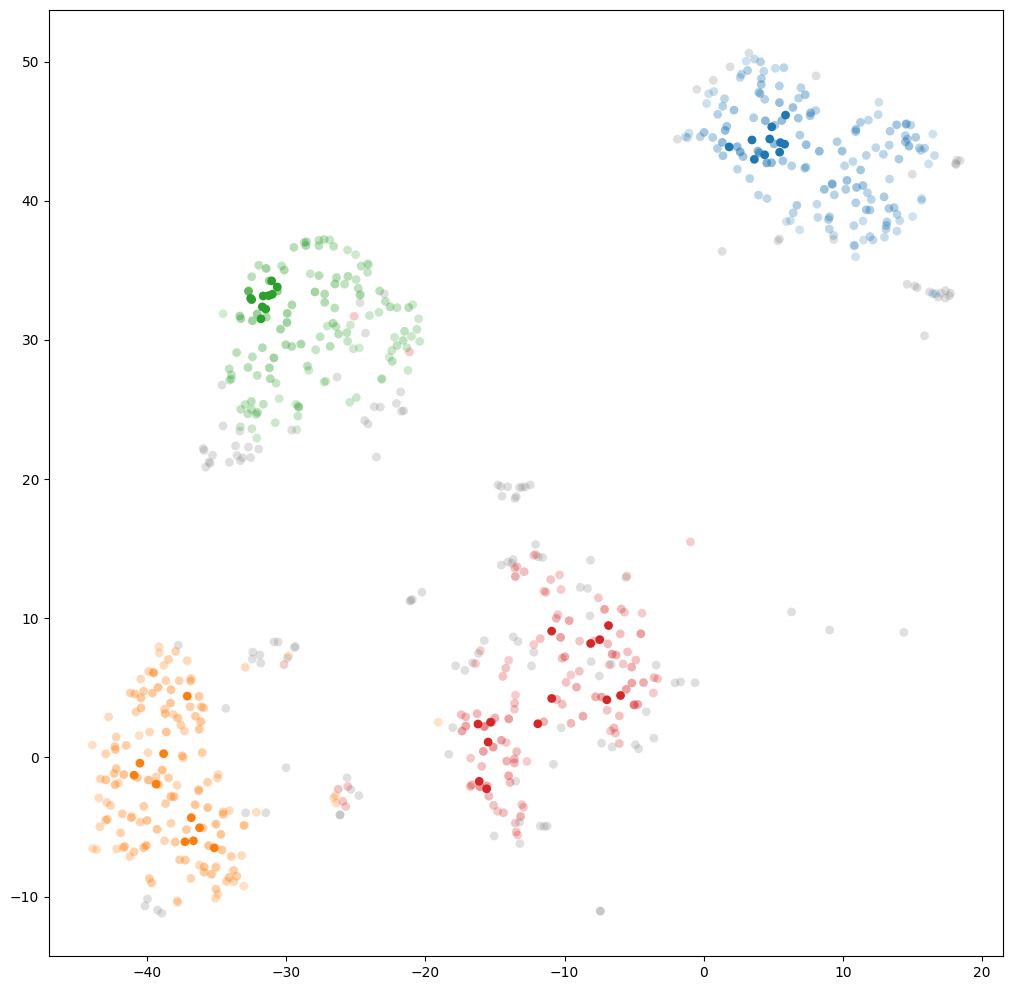

In [213]:
fig, ax = plt.subplots(figsize=(14, 10))

# Plot the scatter points
ax.scatter(*reduced_projection_orig.T, s=40, linewidth=0, c=r_new_colors, edgecolors='none')

# Force the exact same aspect ratio as the pie plot
ax.set_aspect('equal', adjustable='box')

# Apply the exact same axis limits (r_lim) used in the pie plot
ax.set_xlim(r_lim[0], r_lim[1])
ax.set_ylim(r_lim[2], r_lim[3])

plt.tight_layout()
plt.savefig('images/reclustering_2378', bbox_inches='tight', pad_inches=0.1)
plt.show()

In [ ]:
#r_lim = [-20, 5, -15, 55]

In [207]:
# Draw a small pie at each projection point showing subset_membership for subset_labels

def plot_projection_with_pies(projection, subset_membership, subset_labels, color_palette, lim, figsize=(12, 10), size_frac=0.02):
    """Plot a small pie at each 2D point in `projection`.

    - `subset_membership` should be an (n_points, n_clusters) membership matrix.
    - `subset_labels` is an iterable of cluster labels to show as slices in the pie.
    - `color_palette` is a sequence of RGB tuples (0..1) or matplotlib color specs.
    """
    fig, ax = plt.subplots(figsize=figsize)
    # radius (in data units) proportional to data span
    x_span = np.ptp(projection[:, 0]) if projection.shape[0] > 0 else 1.0
    y_span = np.ptp(projection[:, 1]) if projection.shape[0] > 0 else 1.0
    r = size_frac * max(x_span, y_span)

    cols = np.array(subset_labels, dtype=int)
    # prepare colors for subset labels (fall back to gray)
    n_pal = len(color_palette)
    colors = {lab: color_palette[int(lab) % n_pal] if int(lab) >= 0 else (0.5, 0.5, 0.5) for lab in cols}

    for i, (x, y) in enumerate(projection):
        vals = np.array(subset_membership[i])
        sel = vals[cols]
        total = float(sel.sum())
        if total <= 0:
            # draw a small gray dot if no membership in subset
            ax.scatter(x, y, color='lightgray', s=(r * 1000), linewidths=0, zorder=1)
            continue
        start = 0.0
        for lab, v in zip(cols, sel):
            if v <= 0:
                continue
            theta1 = 360.0 * start
            theta2 = 360.0 * (start + v / total)
            wedge = Wedge((x, y), r, theta1, theta2, facecolor=colors[int(lab)], edgecolor='none', linewidth=0, zorder=2)
            ax.add_patch(wedge)
            start += v / total

    # Legend for subset labels
    legend_handles = [Patch(facecolor=colors[int(l)], label=f'Cluster {l}') for l in cols]
    # ax.legend(handles=legend_handles, bbox_to_anchor=(1.02, 1), loc='upper left')
    ax.set_aspect('equal', adjustable='box')
    # ax.set_xlabel('TSNE-1')
    # ax.set_ylabel('TSNE-2')
    # ax.set_title('Projection — pie per point (subset membership)')
    plt.xlim(lim[0], lim[1])
    plt.ylim(lim[2], lim[3])
    plt.tight_layout()
    return fig, ax

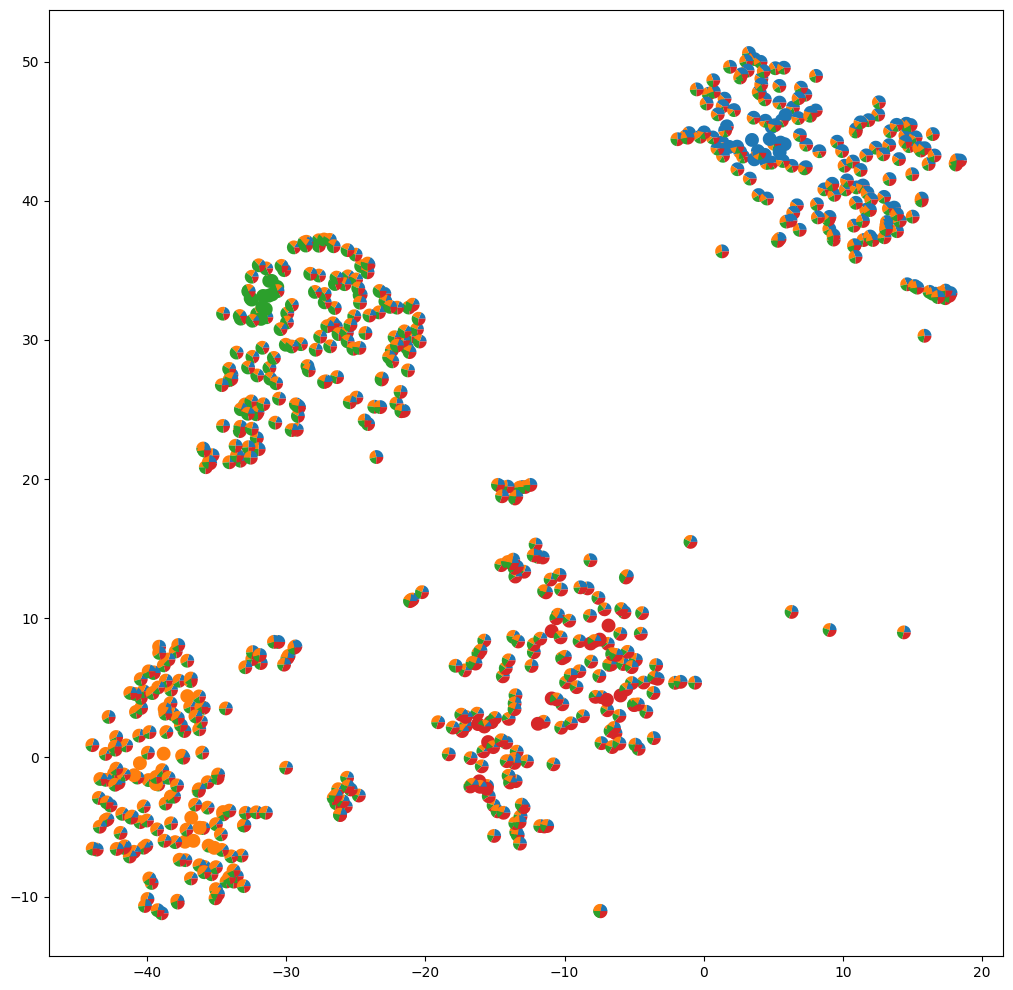

In [214]:
# Plot the piecharts
fig, ax = plot_projection_with_pies(reduced_projection_orig, r_soft_membership, [0,1,2,3], r_hard_color_palette, r_lim, figsize=(14,10), size_frac=0.008)
plt.savefig("images/piechart_2378", bbox_inches='tight', pad_inches=0.1)
plt.show()

In [243]:
subset_labels

[1, 2, 11]

In [250]:
from matplotlib.patches import Wedge, Patch
import numpy as np

def plot_projection_with_pies(ax, projection, subset_membership, subset_labels, color_palette, size_frac=0.06):
    """Plot a small pie at each 2D point onto the provided axis (`ax`)."""
    
    x_span = np.ptp(projection[:, 0]) if projection.shape[0] > 0 else 1.0
    y_span = np.ptp(projection[:, 1]) if projection.shape[0] > 0 else 1.0
    r = size_frac * max(x_span, y_span)

    cols = np.array(subset_labels, dtype=int)
    n_pal = len(color_palette)
    colors = {lab: color_palette[int(lab) % n_pal] if int(lab) >= 0 else (0.5, 0.5, 0.5) for lab in cols}

    for i, (x, y) in enumerate(projection):
        vals = np.array(subset_membership[i])
        sel = vals[cols]
        total = float(sel.sum())
        
        if total <= 0:
            ax.scatter(x, y, color='lightgray', s=(r * 1000), linewidths=0, zorder=1)
            continue
            
        start = 0.0
        for lab, v in zip(cols, sel):
            if v <= 0:
                continue
            theta1 = 360.0 * start
            theta2 = 360.0 * (start + v / total)
            wedge = Wedge((x, y), r, theta1, theta2, facecolor=colors[int(lab)], edgecolor='none', linewidth=0, zorder=2)
            ax.add_patch(wedge)
            start += v / total

# Legend for subset labels
    # print(cols)



    l_new = [2, 1, 0, 3]
    ind_new = [7, 3, 2, 8]
    # legend_handles = [Patch(facecolor=colors[int(l)], label=f'Cluster {l}') for l in cols]
    legend_handles = [Patch(facecolor=colors[int(l)], label=f'Label {ind_new[l]}') for l in l_new]
    ax.legend(handles=legend_handles, loc='upper left')

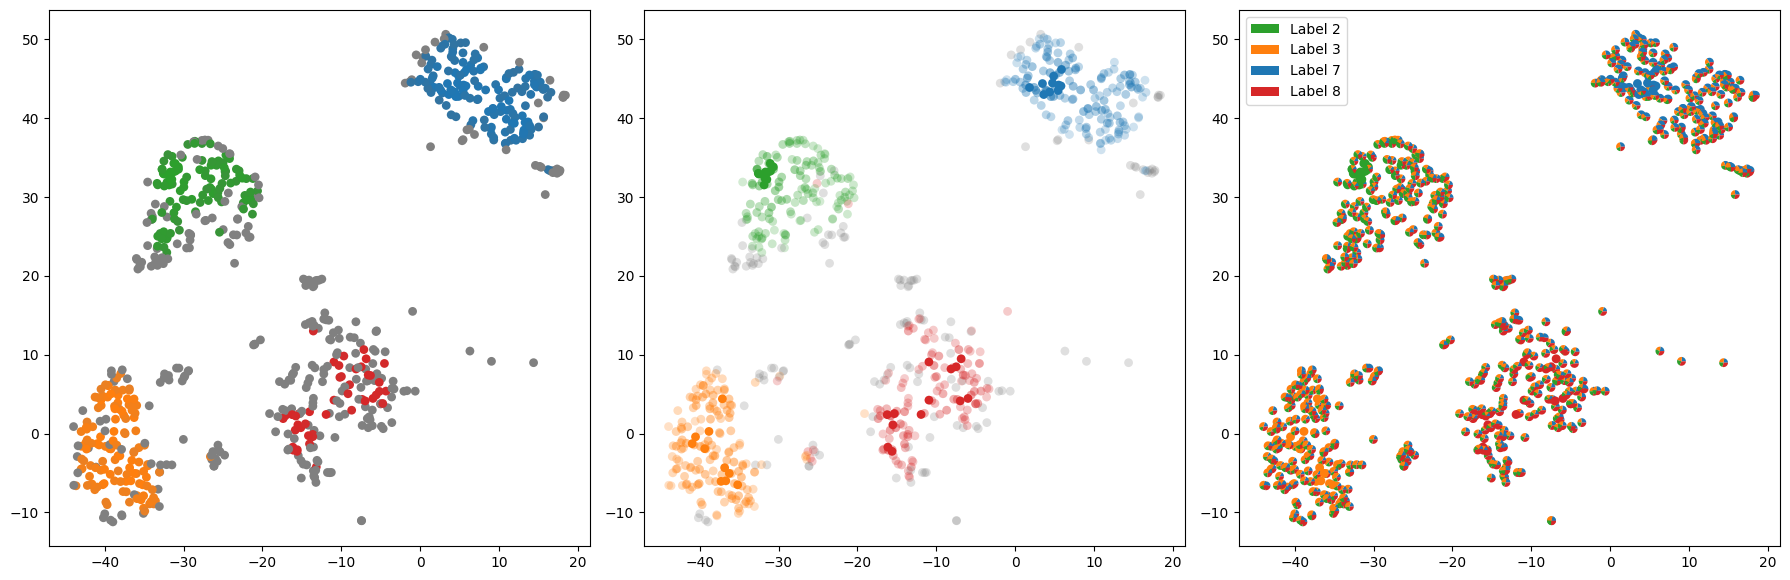

In [253]:
import matplotlib.pyplot as plt

# Create a figure with 1 row and 3 columns. 
# Make it wide (e.g., 18 units wide, 6 units tall) to accommodate 3 plots side-by-side.
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ---------------------------------------------------------
# Plot 1: Standard Scatter on axes[0]
# ---------------------------------------------------------
axes[0].scatter(*reduced_projection_orig.T, s=40, linewidth=0, c=r_hard_member_colors, edgecolors='none')
# axes[0].set_title("Standard Scatter")

# ---------------------------------------------------------
# Plot 2: Pie Plot on axes[1]
# ---------------------------------------------------------
axes[1].scatter(*reduced_projection_orig.T, s=40, linewidth=0, c=r_new_colors, edgecolors='none')
# axes[1].set_title("Subset Membership Pies")

# ---------------------------------------------------------
# Plot 3: Your third image on axes[2]
# ---------------------------------------------------------
# (Replace this with whatever your 3rd plot is supposed to be)

plot_projection_with_pies(axes[2], reduced_projection_orig, r_soft_membership, [0,1,2,3], r_hard_color_palette, size_frac=0.009)
# axes[2].set_title("Third Plot")


# ---------------------------------------------------------
# Apply uniform limits and aspect ratio to ALL panels
# ---------------------------------------------------------
for ax in axes:
    # Force 1:1 aspect ratio and allow the box to adjust, removing warnings
    ax.set_aspect('equal', adjustable='box')
    
    # Apply uniform limits
    ax.set_xlim(r_lim[0], r_lim[1])
    ax.set_ylim(r_lim[2], r_lim[3])
    
    # Optional: remove axes ticks/labels for a cleaner look
    # ax.axis('off') 

# Clean up spacing and save with tight bounding box to cut out blank borders
plt.tight_layout()
plt.savefig("images/horizontal_panel_label.pdf", bbox_inches='tight', dpi=300, pad_inches=0.1)
plt.show()

